# Evaluate Classification Results for HydraBLE Classification Hard

In [1]:
import os
from pathlib import Path

os.chdir(Path.cwd().parents[0])
print("Now in:", Path.cwd())

dataPathProcessed = str(Path.cwd()) + r"\data\csv" + r"\Processed Files\\"
logitsPath = str(Path.cwd()) + r"\out\modeling\logits_and_labels\\classification_data_augmented\\"
plotPath = str(Path.cwd()) + r"\out\plots\modeling\classification_data_augmented\\"
tablePath = str(Path.cwd()) + r"\out\tables\modeling\classification_data_augmented\\"

Now in: C:\Users\stsax\OneDrive\Studium\9. Semester\Masterarbeit\Repository


In [2]:
import pandas as pd
from data_processing.LabelLut import LABEL_OTHER_DEVICE
from evaluation_framework import Experiment, StaticMetricCollection, OSCRCurve, AccuracyOpenSet

pkt_df_test = pd.read_parquet(dataPathProcessed + r"classification_dataset_v2_test.parquet")

known_labels = sorted(list(pkt_df_test['Label'].unique()))
known_labels.remove(LABEL_OTHER_DEVICE)

label_lut = {i: label for i, label in enumerate(known_labels)}
label_id_unknown = len(label_lut)
label_lut[label_id_unknown] = LABEL_OTHER_DEVICE

PRECISION = 4
H_VALS = (1,2,4,8)

config = StaticMetricCollection([OSCRCurve(unknown_label=label_id_unknown, precision=PRECISION),
                                 AccuracyOpenSet(unknown_label=label_id_unknown, precision=PRECISION, average='macro'),
                                 AccuracyOpenSet(unknown_label=label_id_unknown, precision=PRECISION, average='micro'),
                                 AccuracyOpenSet(unknown_label=label_id_unknown, precision=PRECISION, average='binary')]
                                )

In [3]:
label_lut

{0: 'Apple Device',
 1: 'Apple Find My Device (offline)',
 2: 'Apple Find My Device (online)',
 3: 'Apple Find My Tracker (lost)',
 4: 'Apple Find My Tracker (nearby)',
 5: 'Apple Find My Tracker (unpaired)',
 6: 'Apple Find My Tracker Gen 2 (lost)',
 7: 'Apple Find My Tracker Gen 2 (nearby)',
 8: 'DULT (lost)',
 9: 'DULT (nearby)',
 10: 'Google Find My Tracker (lost)',
 11: 'Google Find My Tracker (unpaired)',
 12: 'Samsung SmartThings Tracker (lost)',
 13: 'Samsung SmartThings Tracker (nearby)',
 14: 'Tile Tracker (lost)',
 15: 'Other Device'}

In [4]:
import torch

thresholds = dict()
threshold_indexes = dict()
for h in H_VALS:
    logits = torch.load(logitsPath + f"logits_classification_h={h}_augmented_validation.pt")
    targets  = torch.load(logitsPath + f"label_ids_classification_h={h}_augmented_validation.pt")

    exp = Experiment(name="Test-Experiment")

    small_config =  StaticMetricCollection([AccuracyOpenSet(unknown_label=label_id_unknown, precision=PRECISION, average='micro')])

    exp.configure(small_config)
    exp.add_data(logits=logits, targets=targets)

    score = exp.score()

    acc = score['Accuracy Open Set (micro)']
    threshold = acc.argmax() / len(acc)

    thresholds[h] = float(threshold)
    threshold_indexes[h] = int(acc.argmax())


Accuracy Open Set (micro) started computing...
Accuracy Open Set (micro) finished computing in 0.15 minutes.
Accuracy Open Set (micro) started computing...
Accuracy Open Set (micro) finished computing in 0.14 minutes.
Accuracy Open Set (micro) started computing...
Accuracy Open Set (micro) finished computing in 0.14 minutes.
Accuracy Open Set (micro) started computing...
Accuracy Open Set (micro) finished computing in 0.14 minutes.


In [5]:
print(thresholds)

{1: 0.3056694269180298, 2: 0.45745426416397095, 4: 0.27497249841690063, 8: 0.3800619840621948}


OSCR Curve started computing...
OSCR Curve finished computing in 0.02 minutes.
Accuracy Open Set (macro) started computing...
Accuracy Open Set (macro) finished computing in 0.14 minutes.
Accuracy Open Set (micro) started computing...
Accuracy Open Set (micro) finished computing in 0.15 minutes.
Accuracy Open Set (binary) started computing...
Accuracy Open Set (binary) finished computing in 0.15 minutes.


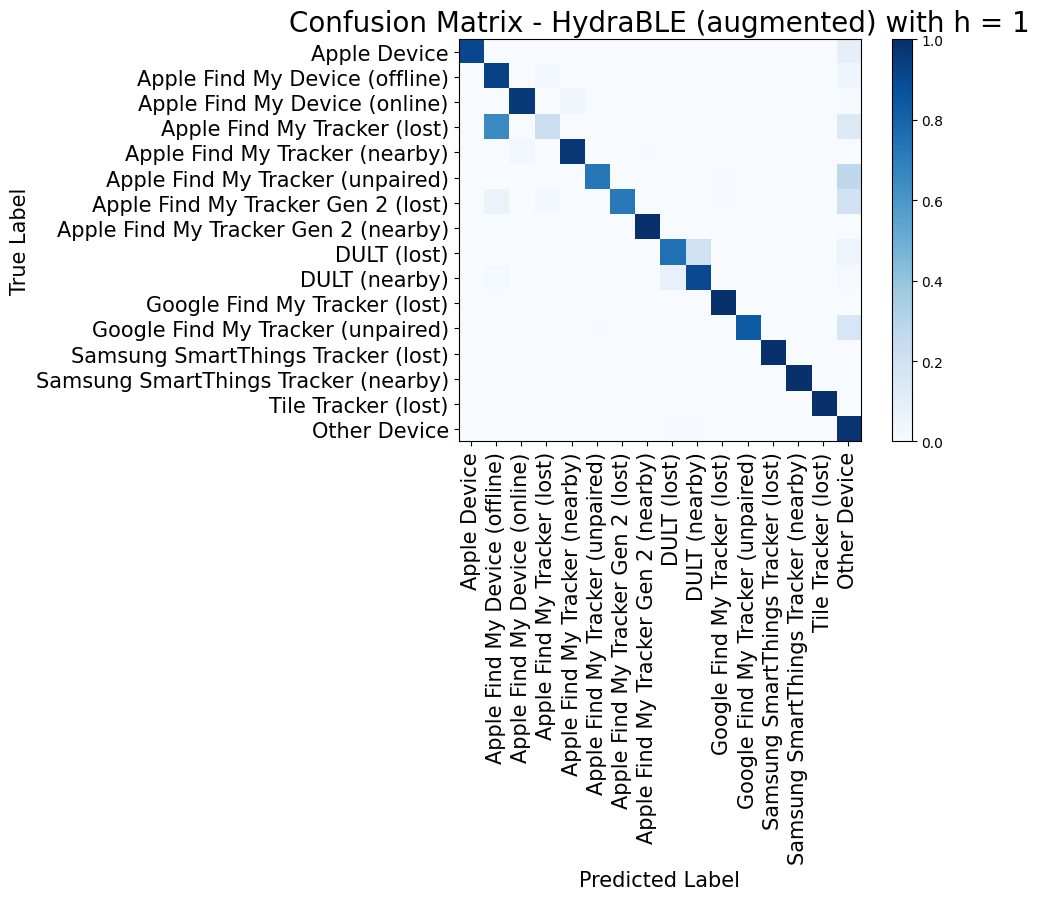

Classification Report - HydraBLE (augmented) with h = 1
                                      precision    recall  f1-score   support

                        Apple Device     0.9733    0.9100    0.9406       200
      Apple Find My Device (offline)     0.5552    0.9300    0.6953       200
       Apple Find My Device (online)     0.9746    0.9600    0.9673       200
        Apple Find My Tracker (lost)     0.8182    0.2250    0.3529       200
      Apple Find My Tracker (nearby)     0.9652    0.9700    0.9676       200
    Apple Find My Tracker (unpaired)     0.9667    0.7250    0.8286       200
  Apple Find My Tracker Gen 2 (lost)     0.9931    0.7200    0.8348       200
Apple Find My Tracker Gen 2 (nearby)     0.9804    1.0000    0.9901       200
                         DULT (lost)     0.8152    0.7500    0.7812       200
                       DULT (nearby)     0.7595    0.9000    0.8238       200
       Google Find My Tracker (lost)     0.9901    1.0000    0.9950       200
   Goog

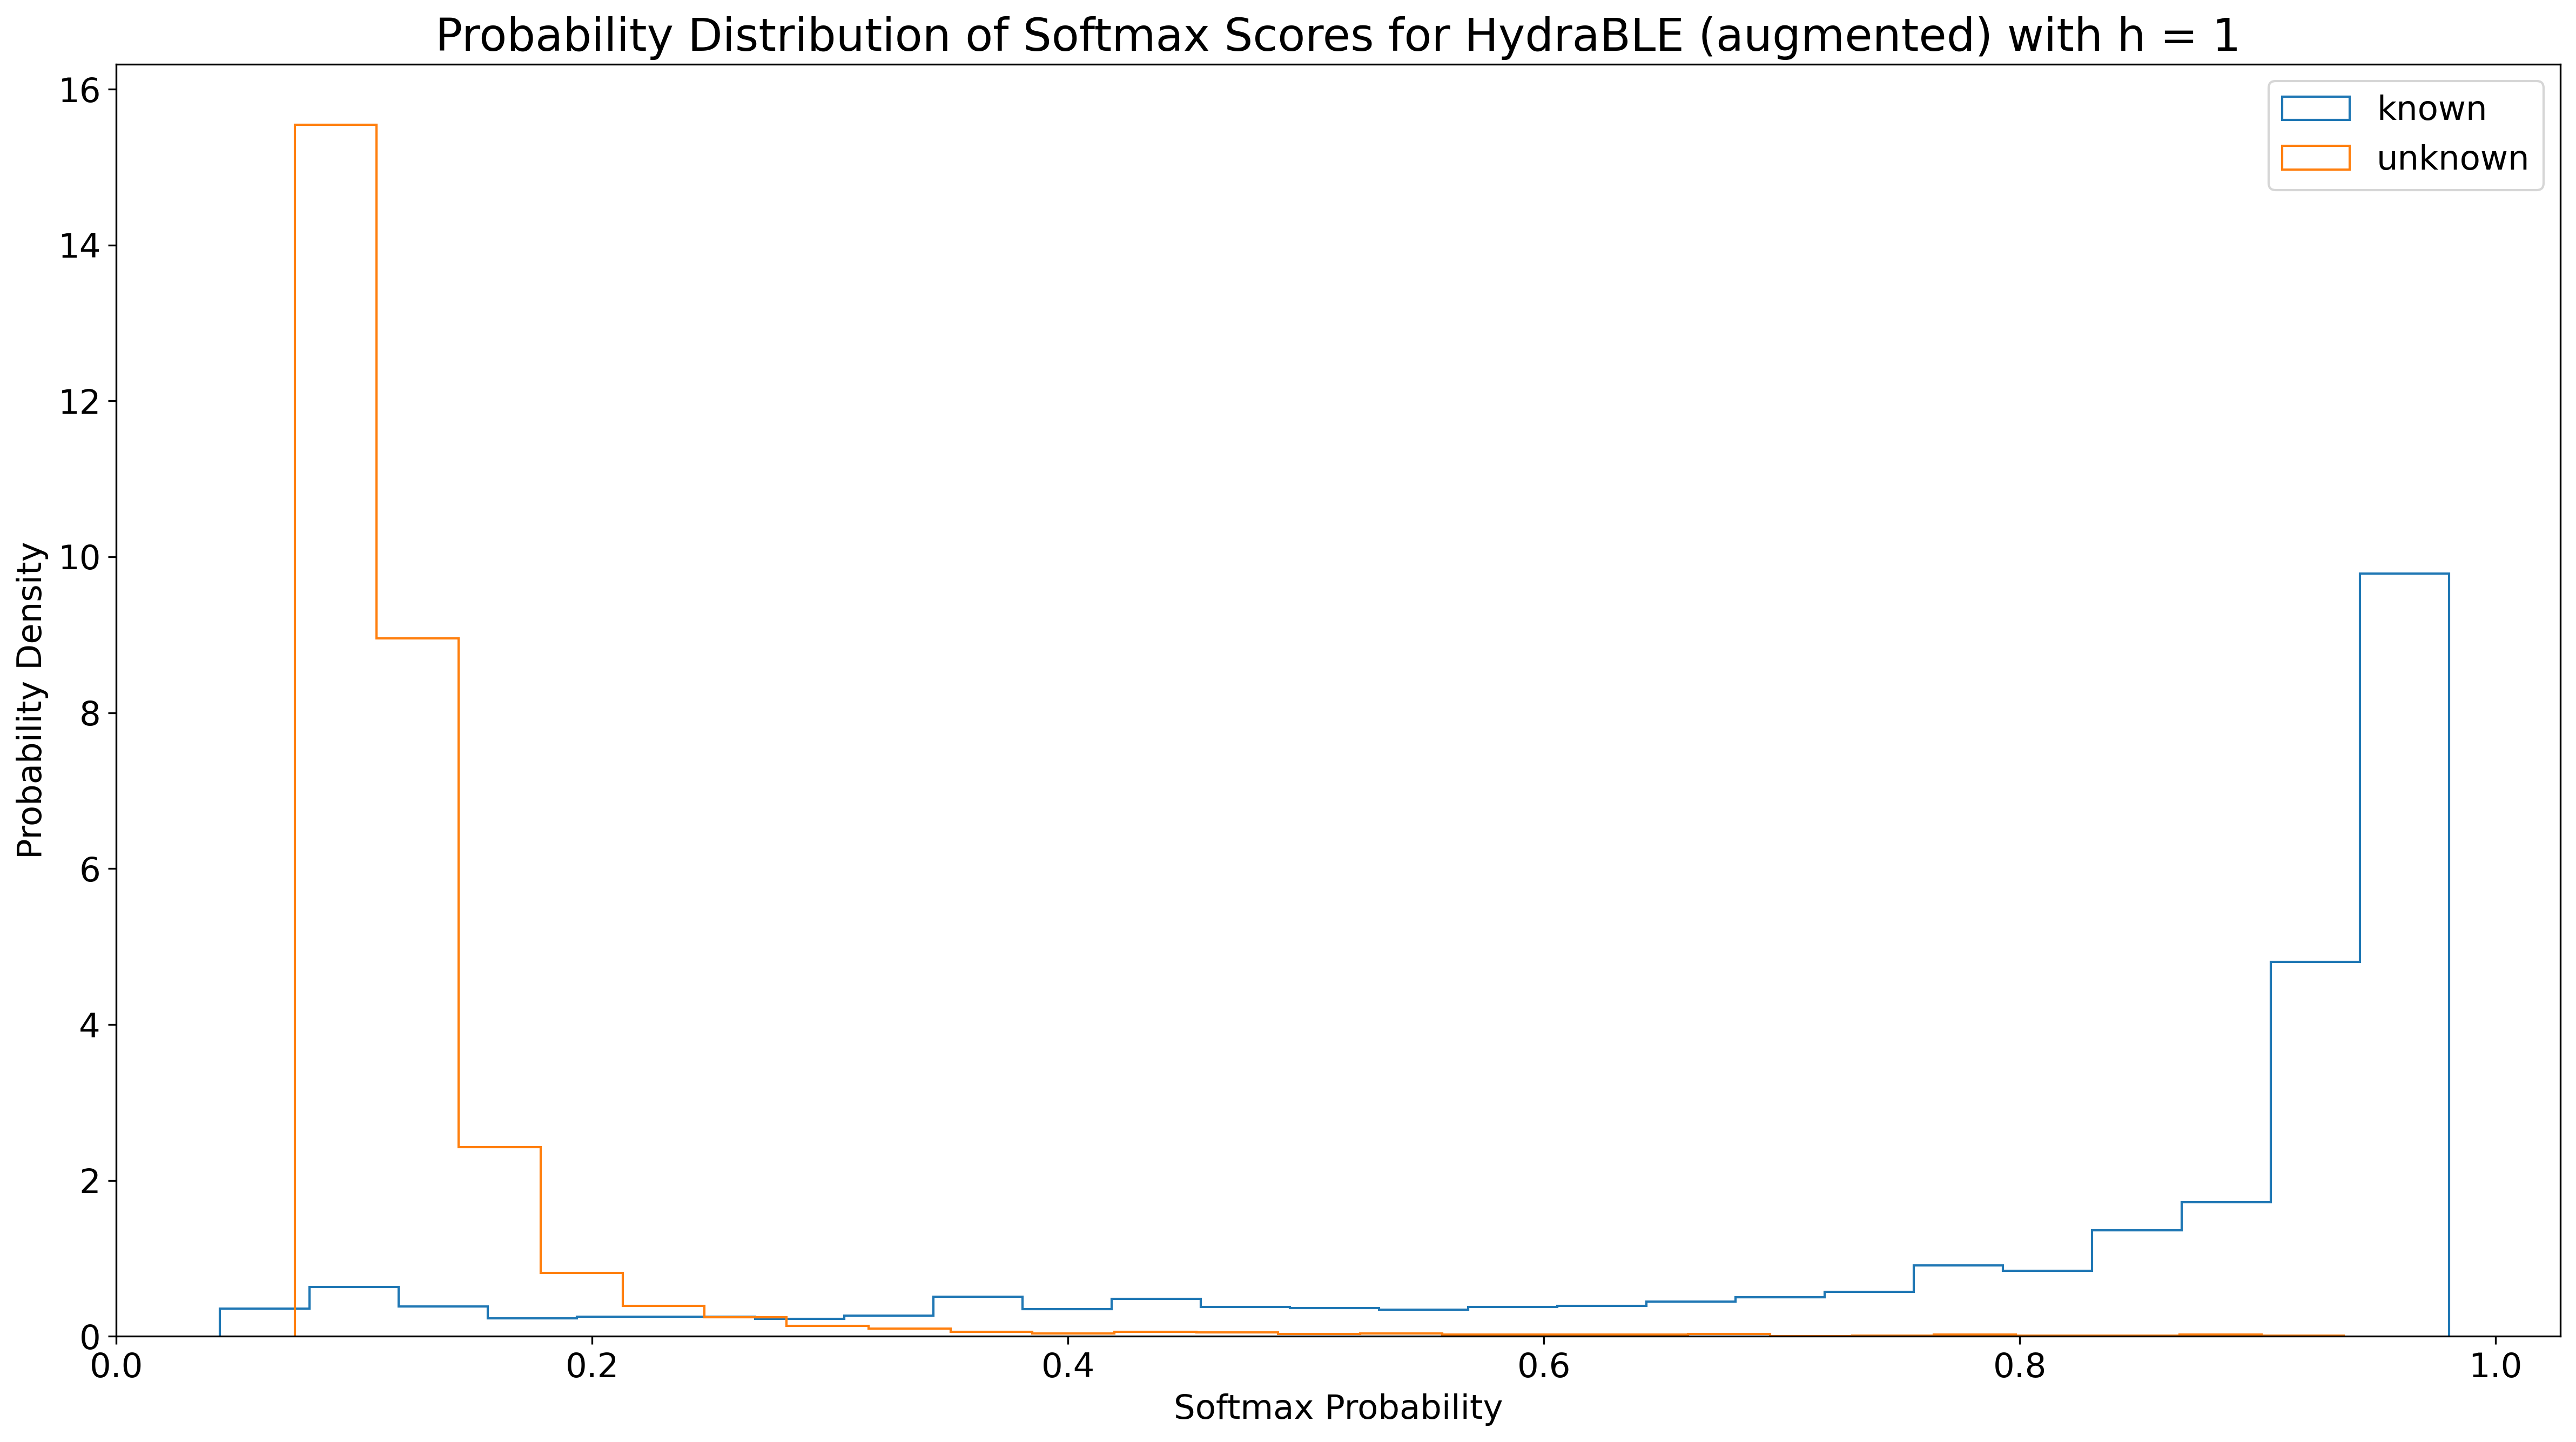

OSCR Curve started computing...
OSCR Curve finished computing in 0.03 minutes.
Accuracy Open Set (macro) started computing...
Accuracy Open Set (macro) finished computing in 0.15 minutes.
Accuracy Open Set (micro) started computing...
Accuracy Open Set (micro) finished computing in 0.14 minutes.
Accuracy Open Set (binary) started computing...
Accuracy Open Set (binary) finished computing in 0.14 minutes.


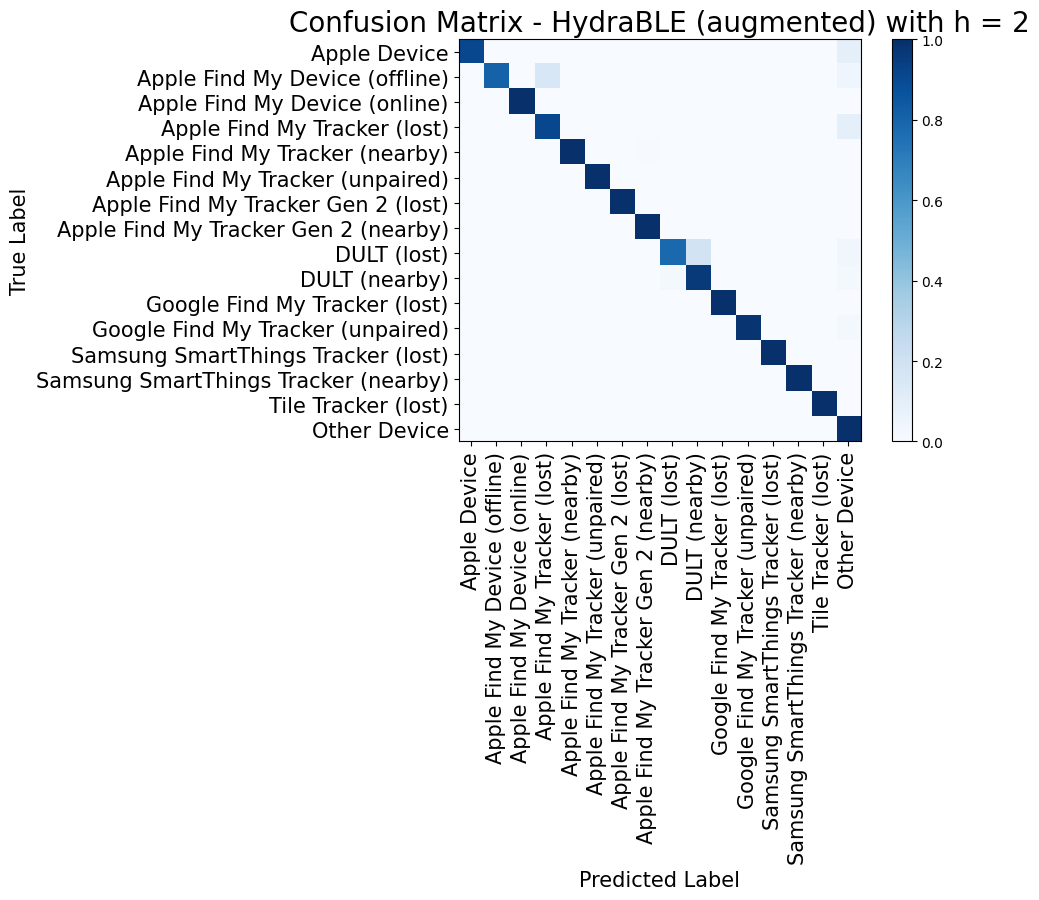

Classification Report - HydraBLE (augmented) with h = 2
                                      precision    recall  f1-score   support

                        Apple Device     1.0000    0.9100    0.9529       200
      Apple Find My Device (offline)     0.9817    0.8050    0.8846       200
       Apple Find My Device (online)     1.0000    1.0000    1.0000       200
        Apple Find My Tracker (lost)     0.8465    0.9100    0.8771       200
      Apple Find My Tracker (nearby)     1.0000    0.9950    0.9975       200
    Apple Find My Tracker (unpaired)     1.0000    1.0000    1.0000       200
  Apple Find My Tracker Gen 2 (lost)     1.0000    1.0000    1.0000       200
Apple Find My Tracker Gen 2 (nearby)     0.9901    1.0000    0.9950       200
                         DULT (lost)     0.9630    0.7800    0.8619       200
                       DULT (nearby)     0.8205    0.9600    0.8848       200
       Google Find My Tracker (lost)     1.0000    1.0000    1.0000       200
   Goog

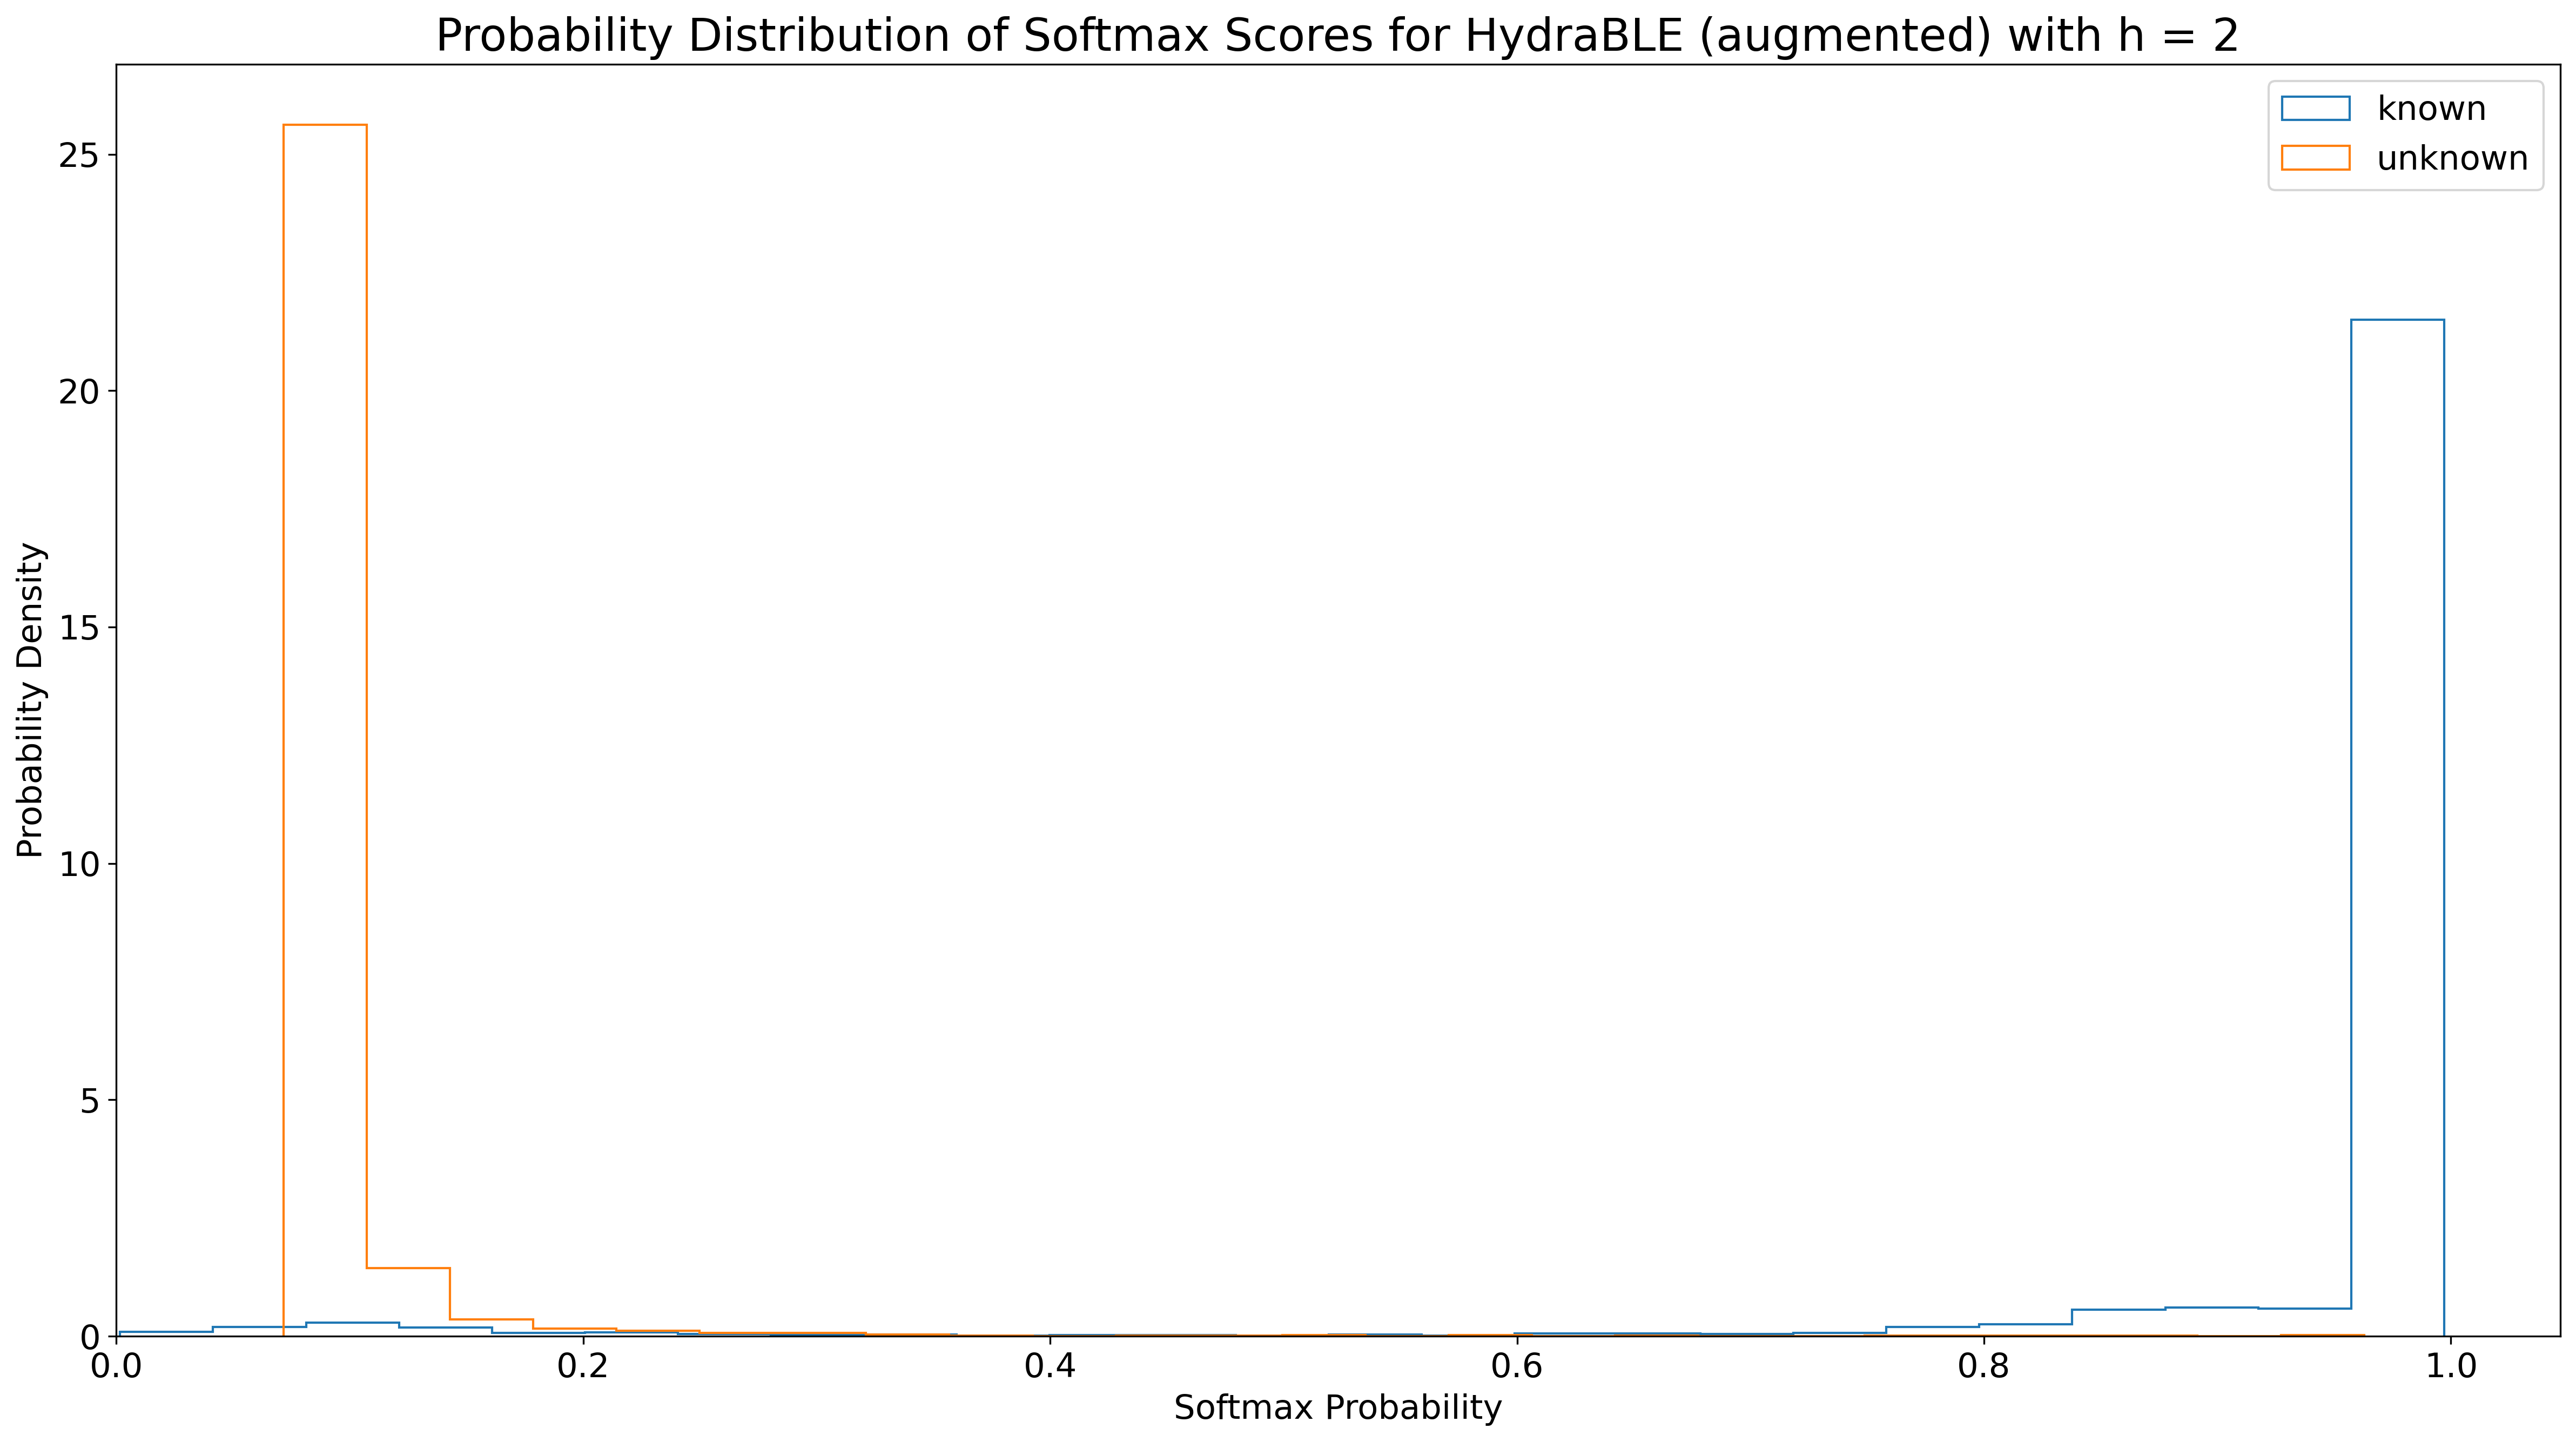

OSCR Curve started computing...
OSCR Curve finished computing in 0.03 minutes.
Accuracy Open Set (macro) started computing...
Accuracy Open Set (macro) finished computing in 0.14 minutes.
Accuracy Open Set (micro) started computing...
Accuracy Open Set (micro) finished computing in 0.14 minutes.
Accuracy Open Set (binary) started computing...
Accuracy Open Set (binary) finished computing in 0.14 minutes.


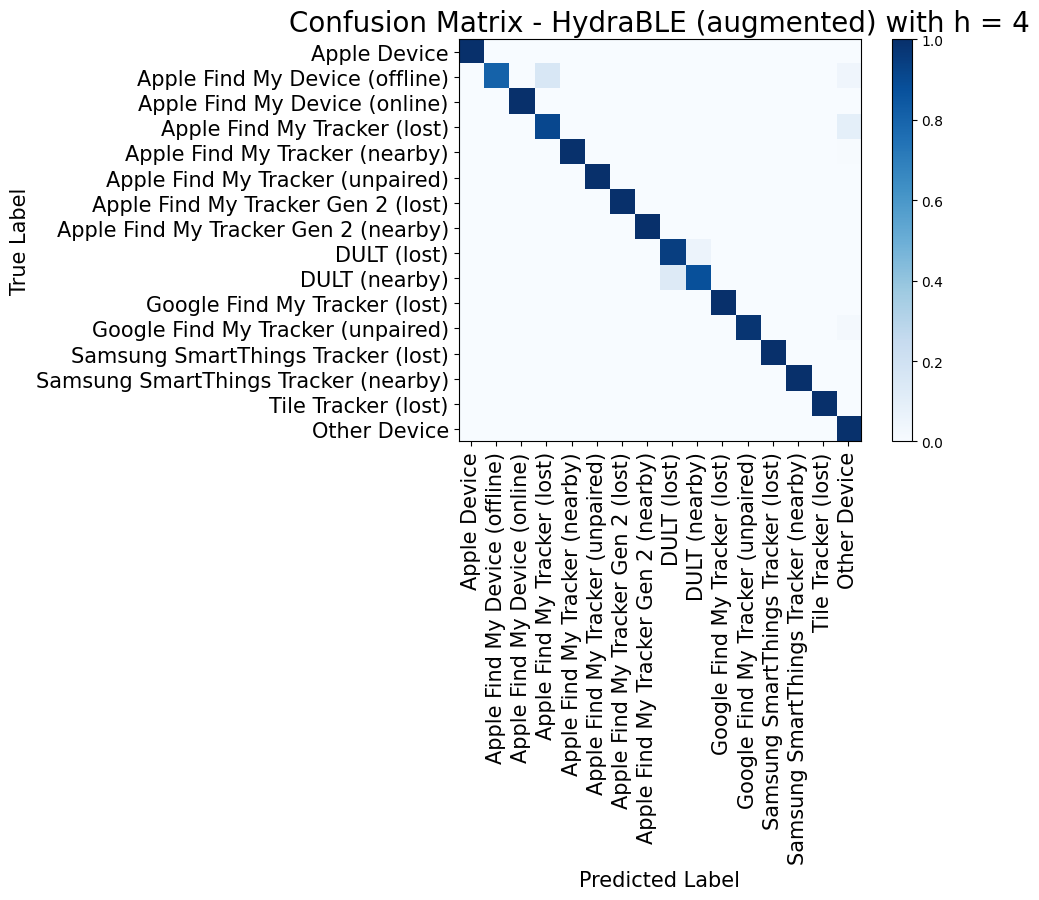

Classification Report - HydraBLE (augmented) with h = 4
                                      precision    recall  f1-score   support

                        Apple Device     0.9804    1.0000    0.9901       200
      Apple Find My Device (offline)     0.9817    0.8050    0.8846       200
       Apple Find My Device (online)     0.9950    1.0000    0.9975       200
        Apple Find My Tracker (lost)     0.8465    0.9100    0.8771       200
      Apple Find My Tracker (nearby)     1.0000    0.9950    0.9975       200
    Apple Find My Tracker (unpaired)     1.0000    1.0000    1.0000       200
  Apple Find My Tracker Gen 2 (lost)     1.0000    1.0000    1.0000       200
Apple Find My Tracker Gen 2 (nearby)     1.0000    1.0000    1.0000       200
                         DULT (lost)     0.8791    0.9450    0.9108       200
                       DULT (nearby)     0.9409    0.8750    0.9067       200
       Google Find My Tracker (lost)     1.0000    1.0000    1.0000       200
   Goog

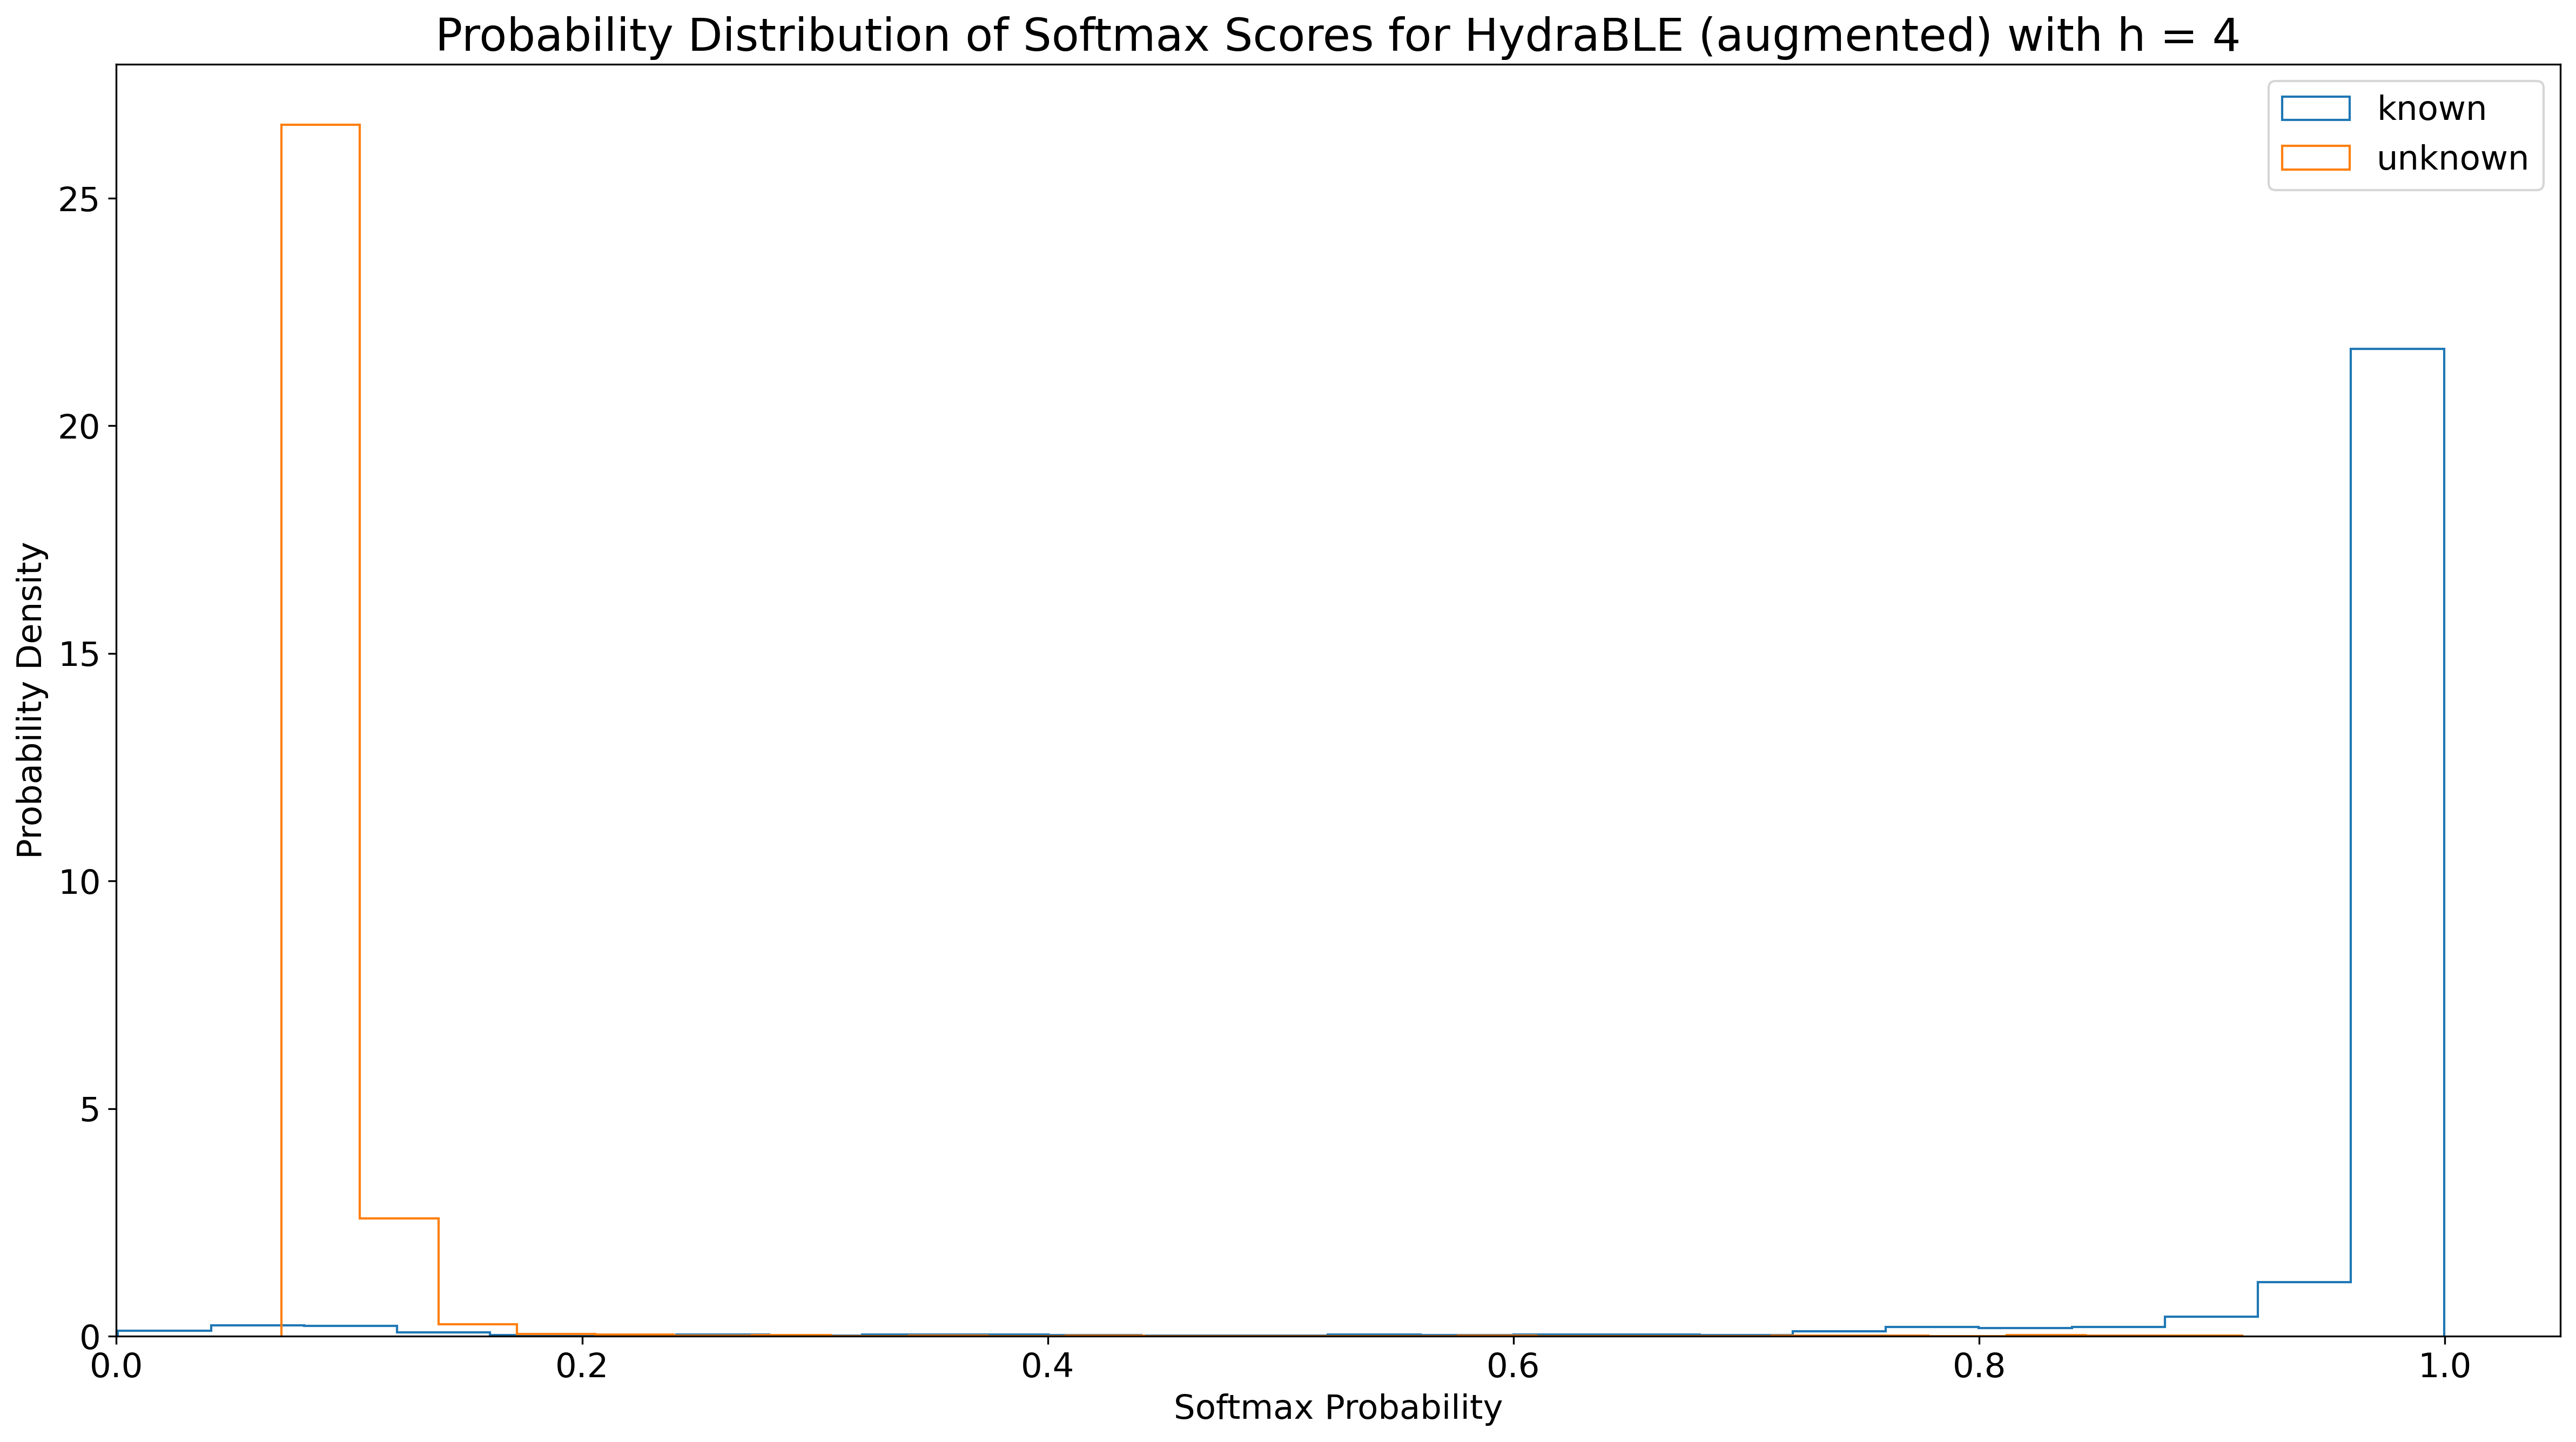

OSCR Curve started computing...
OSCR Curve finished computing in 0.03 minutes.
Accuracy Open Set (macro) started computing...
Accuracy Open Set (macro) finished computing in 0.14 minutes.
Accuracy Open Set (micro) started computing...
Accuracy Open Set (micro) finished computing in 0.14 minutes.
Accuracy Open Set (binary) started computing...
Accuracy Open Set (binary) finished computing in 0.14 minutes.


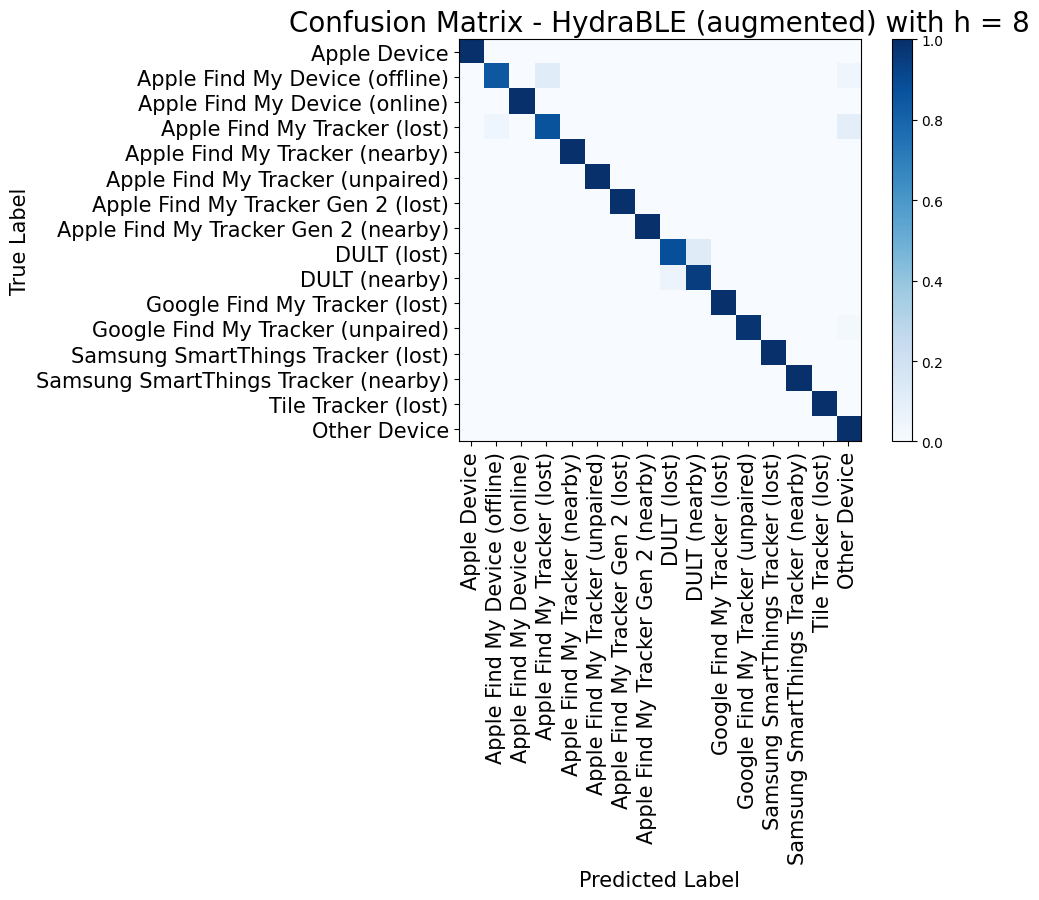

Classification Report - HydraBLE (augmented) with h = 8
                                      precision    recall  f1-score   support

                        Apple Device     0.9709    1.0000    0.9852       200
      Apple Find My Device (offline)     0.9389    0.8450    0.8895       200
       Apple Find My Device (online)     1.0000    1.0000    1.0000       200
        Apple Find My Tracker (lost)     0.8737    0.8650    0.8693       200
      Apple Find My Tracker (nearby)     1.0000    1.0000    1.0000       200
    Apple Find My Tracker (unpaired)     0.9950    1.0000    0.9975       200
  Apple Find My Tracker Gen 2 (lost)     1.0000    1.0000    1.0000       200
Apple Find My Tracker Gen 2 (nearby)     1.0000    1.0000    1.0000       200
                         DULT (lost)     0.9412    0.8800    0.9096       200
                       DULT (nearby)     0.8832    0.9450    0.9130       200
       Google Find My Tracker (lost)     1.0000    1.0000    1.0000       200
   Goog

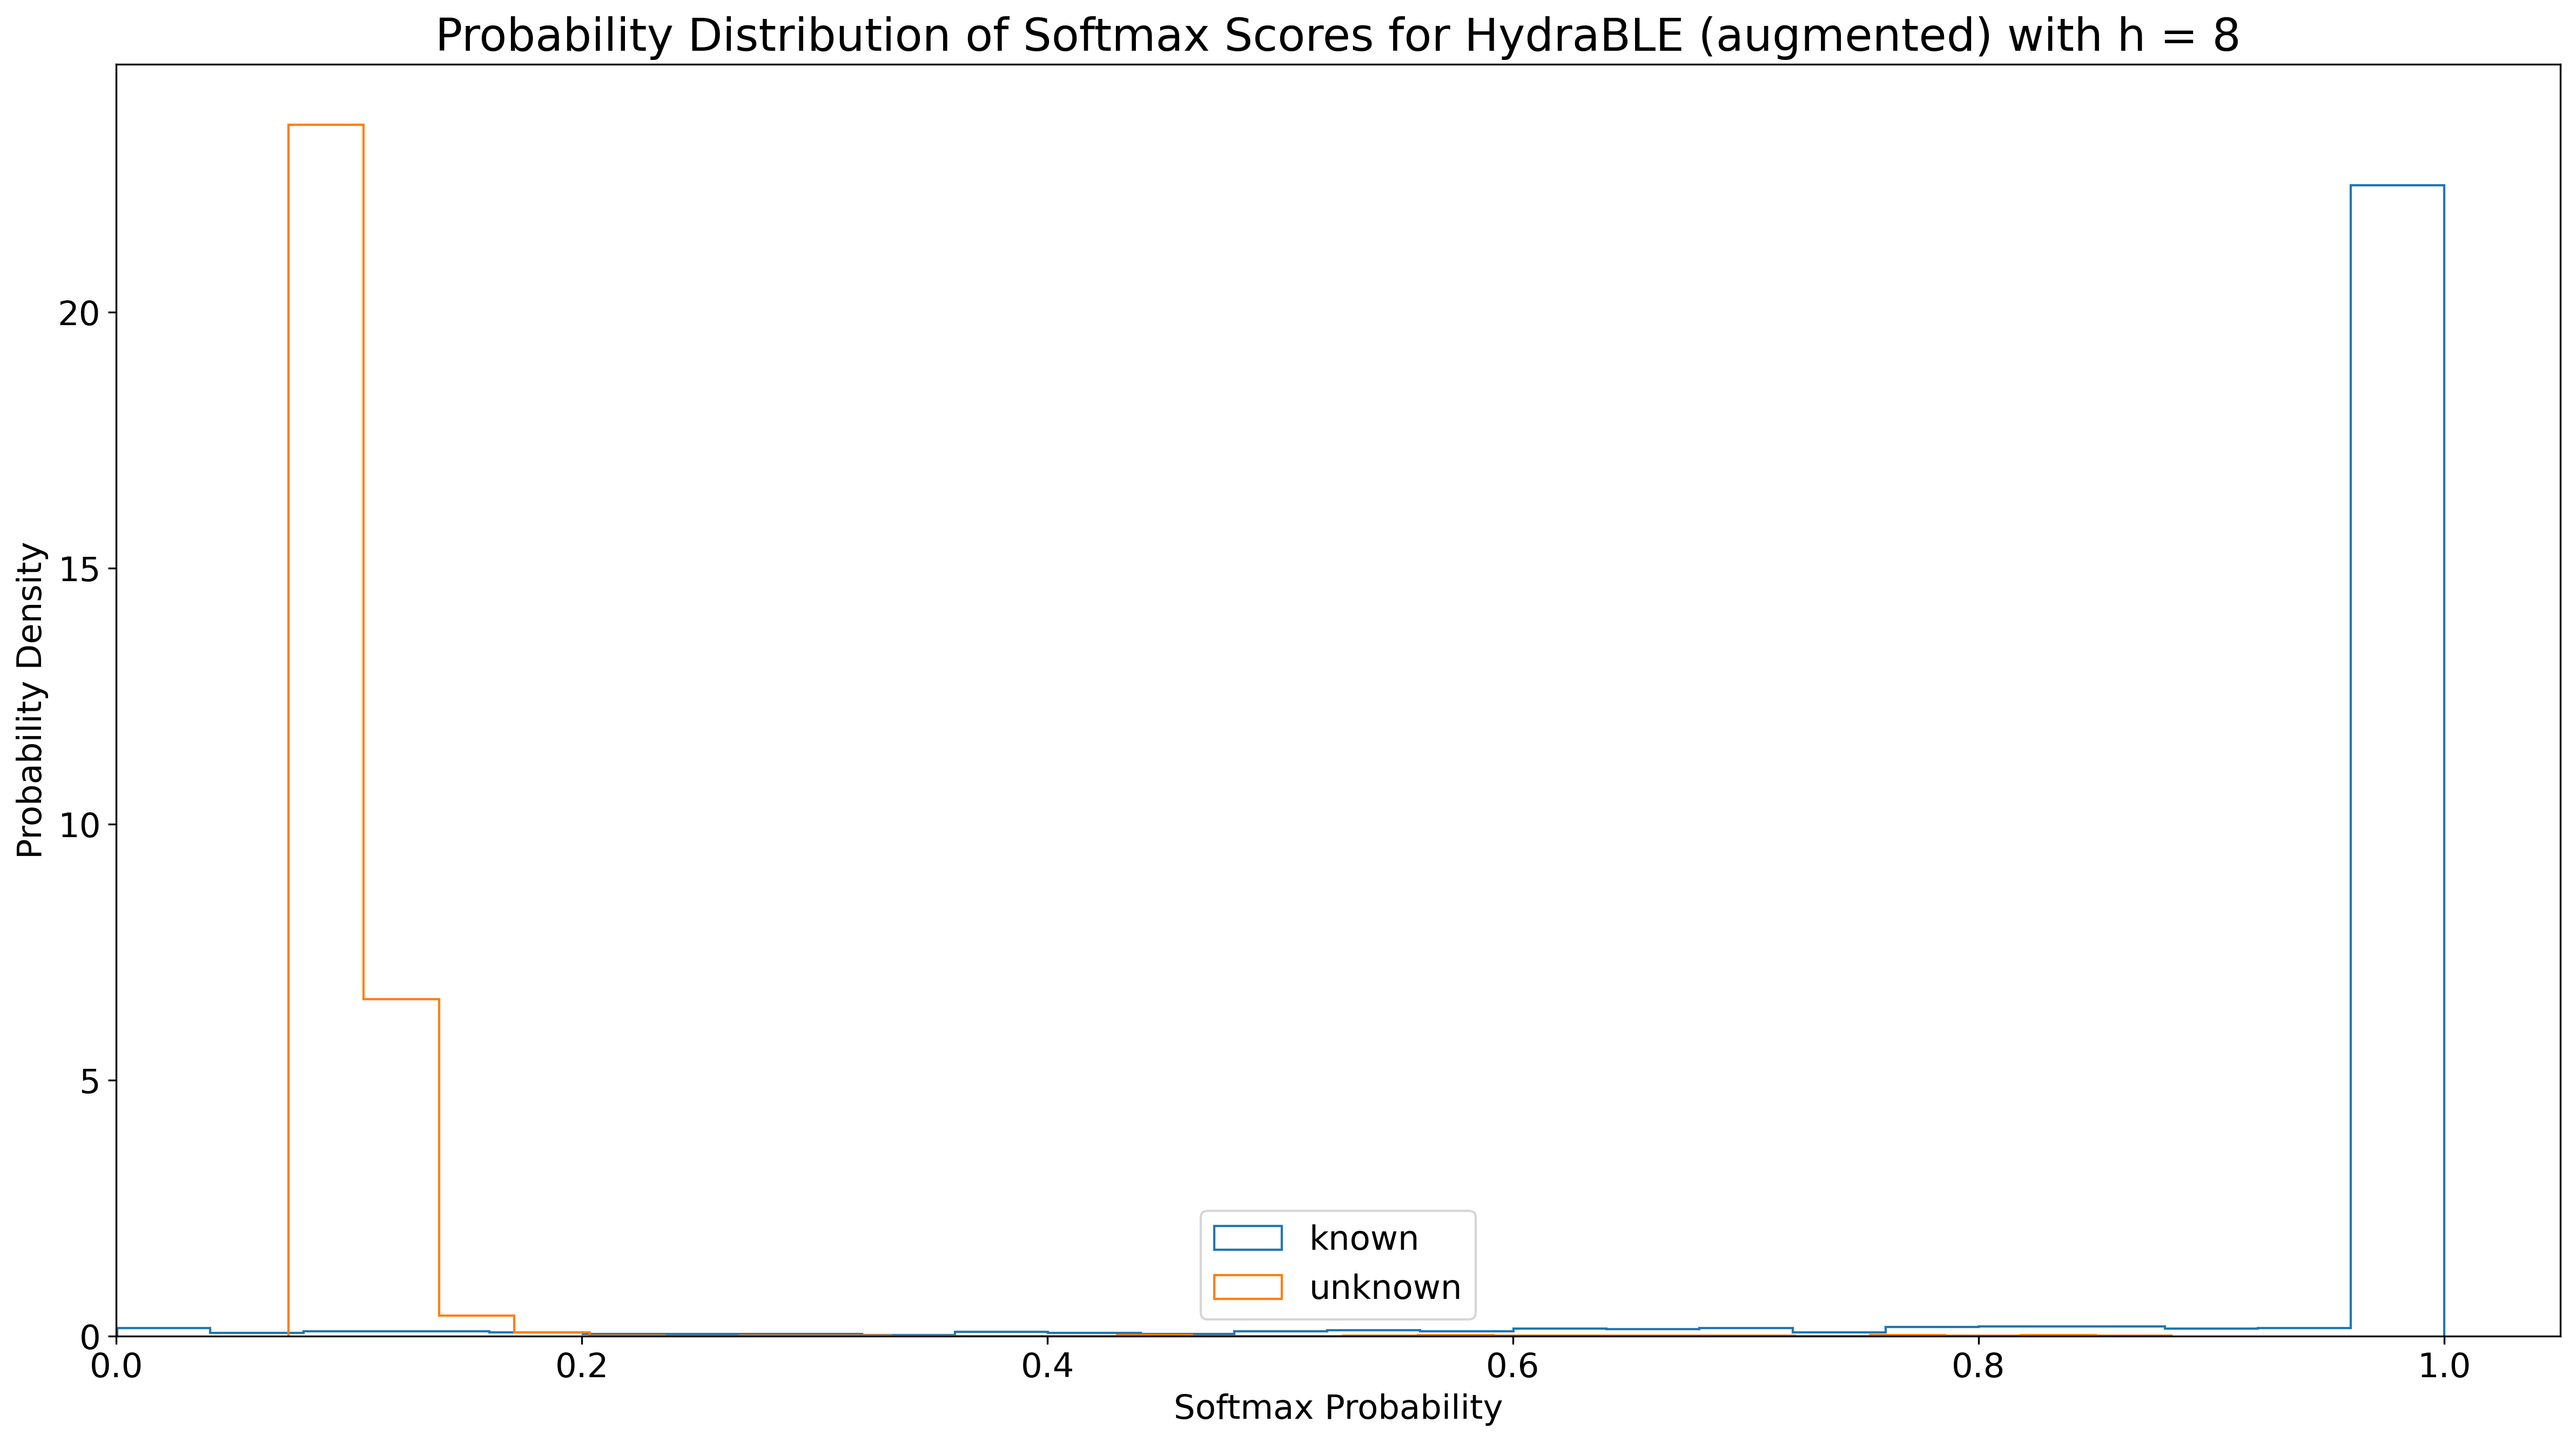

In [6]:
from plotting.src.functions import plotMatrix, FONTSIZE_LABEL, FONTSIZE_TICKS, FONTSIZE_TITLE, plotReport
import matplotlib.pyplot as plt
plt.style.use('default')

oscr_lut = dict()
acc_micro_lut = dict()
acc_macro_lut = dict()
acc_binary_lut = dict()

metric_table = [['Accuracy (micro)', 'Accuracy (macro)', 'Accuracy (binary)', 'CCR at FPR = 1e-1', 'CCR at FPR = 1e-2','CCR at FPR = 1e-3']]

for h in H_VALS:
    logits = torch.load(logitsPath + f"logits_classification_h={h}_augmented_test.pt")
    targets  = torch.load(logitsPath + f"label_ids_classification_h={h}_augmented_test.pt")

    exp = Experiment(name="Test-Experiment")
    exp.configure(config)
    exp.add_data(logits=logits, targets=targets)

    score = exp.score()

    threshold = thresholds[h]
    threshold_idx = threshold_indexes[h]

    probas = torch.nn.functional.softmax(logits, dim = 1)
    max_probas, pred_classes = probas.max(dim=1)

    predictions = torch.where(max_probas >= threshold, pred_classes, torch.full_like(pred_classes, label_id_unknown))

    predictions_text = [label_lut[int(i)] for i in predictions]
    targets_text = [label_lut[int(i)] for i in targets]

    plotMatrix(targets_text, predictions_text, list(label_lut.values()), name=f"HydraBLE (augmented) with h = {h}", savePath=plotPath)
    plotReport(targets_text, predictions_text, list(label_lut.values()), name=f"HydraBLE (augmented) with h = {h}", savePath=tablePath)

    oscr_lut[h] = score['OSCR Curve']
    acc_micro_lut[h] = score['Accuracy Open Set (micro)']
    acc_macro_lut[h] = score['Accuracy Open Set (macro)']
    acc_binary_lut[h] = score['Accuracy Open Set (binary)']


    fprs = oscr_lut[h][:, 0]
    ccrs = oscr_lut[h][:, 1]

    fpr_01_idx = torch.argmin(torch.abs(0.1 - fprs))
    fpr_001_idx = torch.argmin(torch.abs(0.01 - fprs))
    fpr_0001_idx = torch.argmin(torch.abs(0.001 - fprs))

    metric_table.append([float(acc_micro_lut[h][threshold_idx]),
                         float(acc_macro_lut[h][threshold_idx]),
                         float(acc_binary_lut[h][threshold_idx]),
                         float(ccrs[fpr_01_idx]),
                         float(ccrs[fpr_001_idx]),
                         float(ccrs[fpr_0001_idx])
                         ])


    probas = torch.nn.functional.softmax(logits, dim = 1)

    mask_known = (targets != label_id_unknown)
    mask_unknown = (targets == label_id_unknown)

    probas_known = probas[mask_known]
    probas_unknown = probas[mask_unknown]


    true_probas_known = probas_known[torch.arange(len(probas_known)), targets[mask_known]]
    max_probas_unknown, _ = probas_unknown.max(dim = 1)


    plt.figure(figsize=(16, 9), dpi = 300)
    plt.hist(true_probas_known, bins = 25, density=True, histtype='step', label='known')
    plt.hist(max_probas_unknown, bins = 25, density=True, histtype='step', label='unknown')

    plt.ylabel("Probability Density", fontsize=FONTSIZE_LABEL)
    plt.xlabel("Softmax Probability", fontsize=FONTSIZE_LABEL)

    plt.xticks(fontsize=FONTSIZE_TICKS)
    plt.yticks(fontsize=FONTSIZE_TICKS)

    plt.ylim(bottom = 0)
    plt.xlim(left=0)

    title = f"Probability Distribution of Softmax Scores for HydraBLE (augmented) with h = {h}"
    plt.title(title, fontsize=FONTSIZE_TITLE)
    plt.legend(fontsize=FONTSIZE_LABEL)
    plt.tight_layout()

    plt.tight_layout()
    plt.savefig(plotPath + title + ".png", dpi = 300)
    plt.show()


In [7]:
import numpy as np

def plot_curve(lut: dict, title: str, y_label: str):
    plt.style.use('default')
    thresholds_x = np.linspace(0, 1, 10**PRECISION+1)

    plt.figure(figsize=(16, 9), dpi = 300)

    for h, values in lut.items():
        plt.plot(thresholds_x, values, label=f"h = {h}")

    plt.xticks(fontsize=FONTSIZE_TICKS)
    plt.yticks(fontsize=FONTSIZE_TICKS)
    plt.xlabel("Threshold", fontsize=FONTSIZE_LABEL)
    plt.ylim(0, 1.1)
    plt.ylabel(y_label, fontsize=FONTSIZE_LABEL)
    plt.title(title, fontsize=FONTSIZE_TITLE)
    plt.legend()
    plt.tight_layout()
    plt.savefig(plotPath + title + ".png", dpi = 300)
    plt.show()


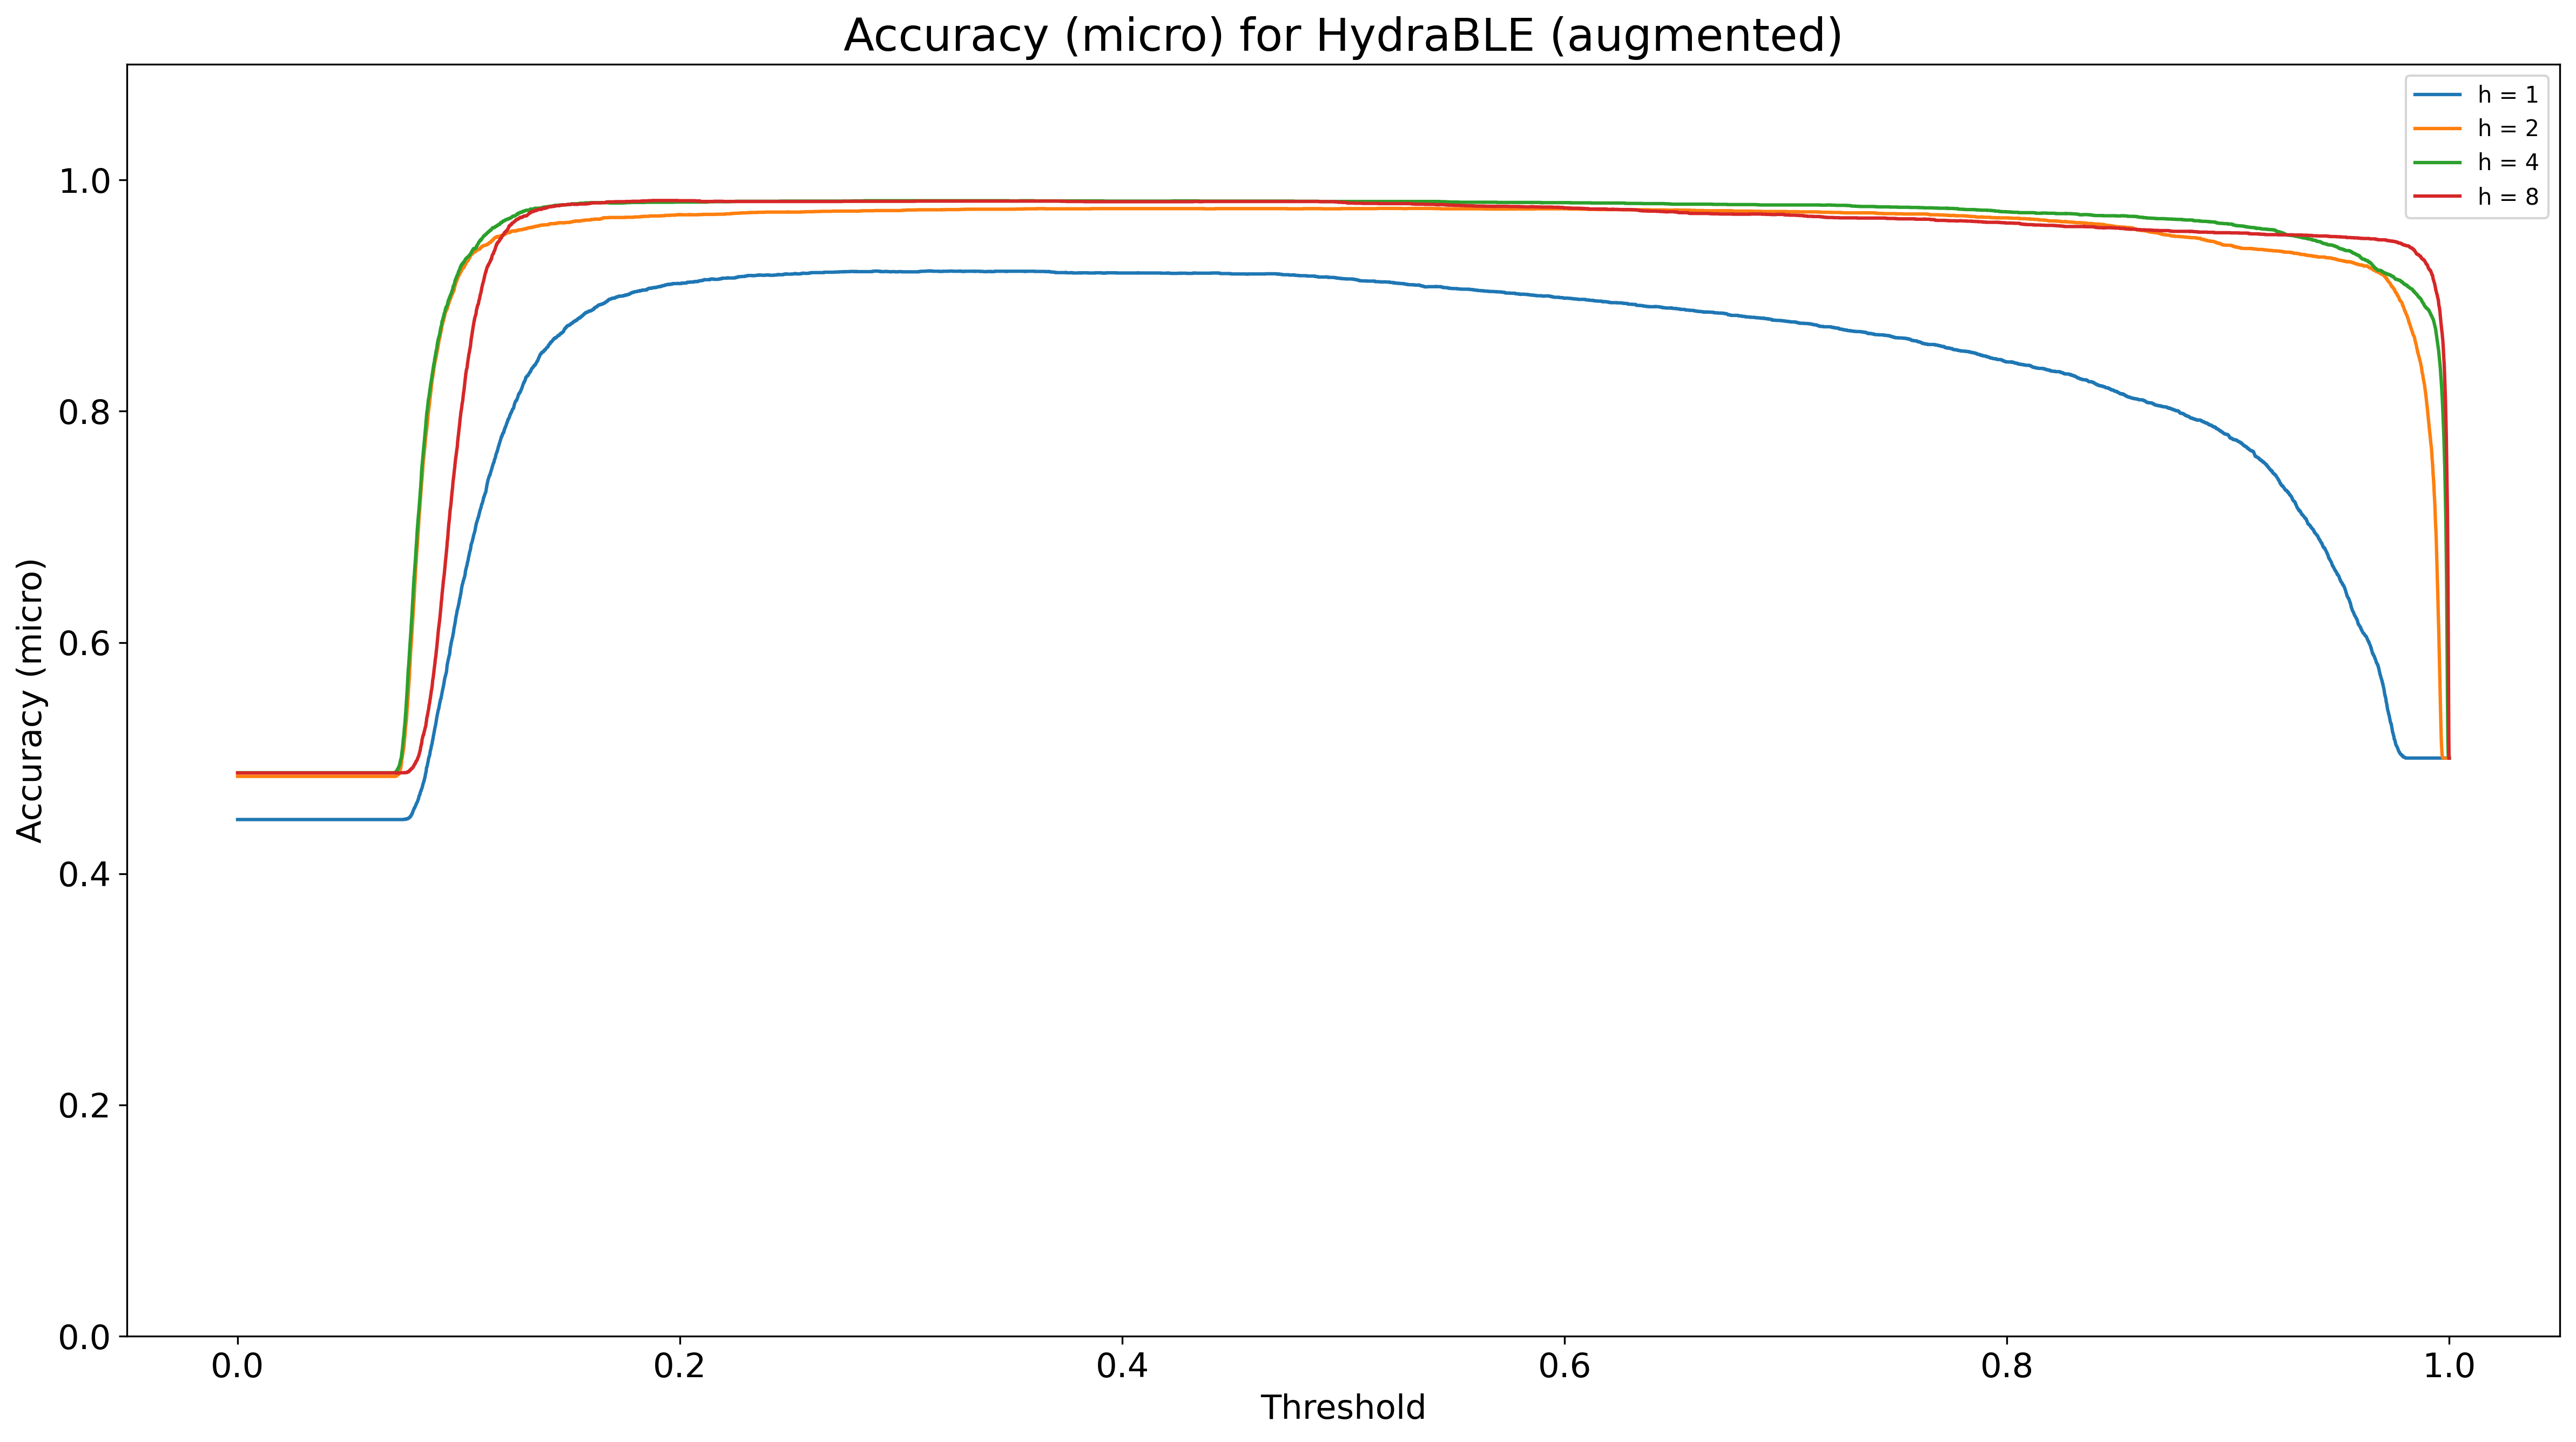

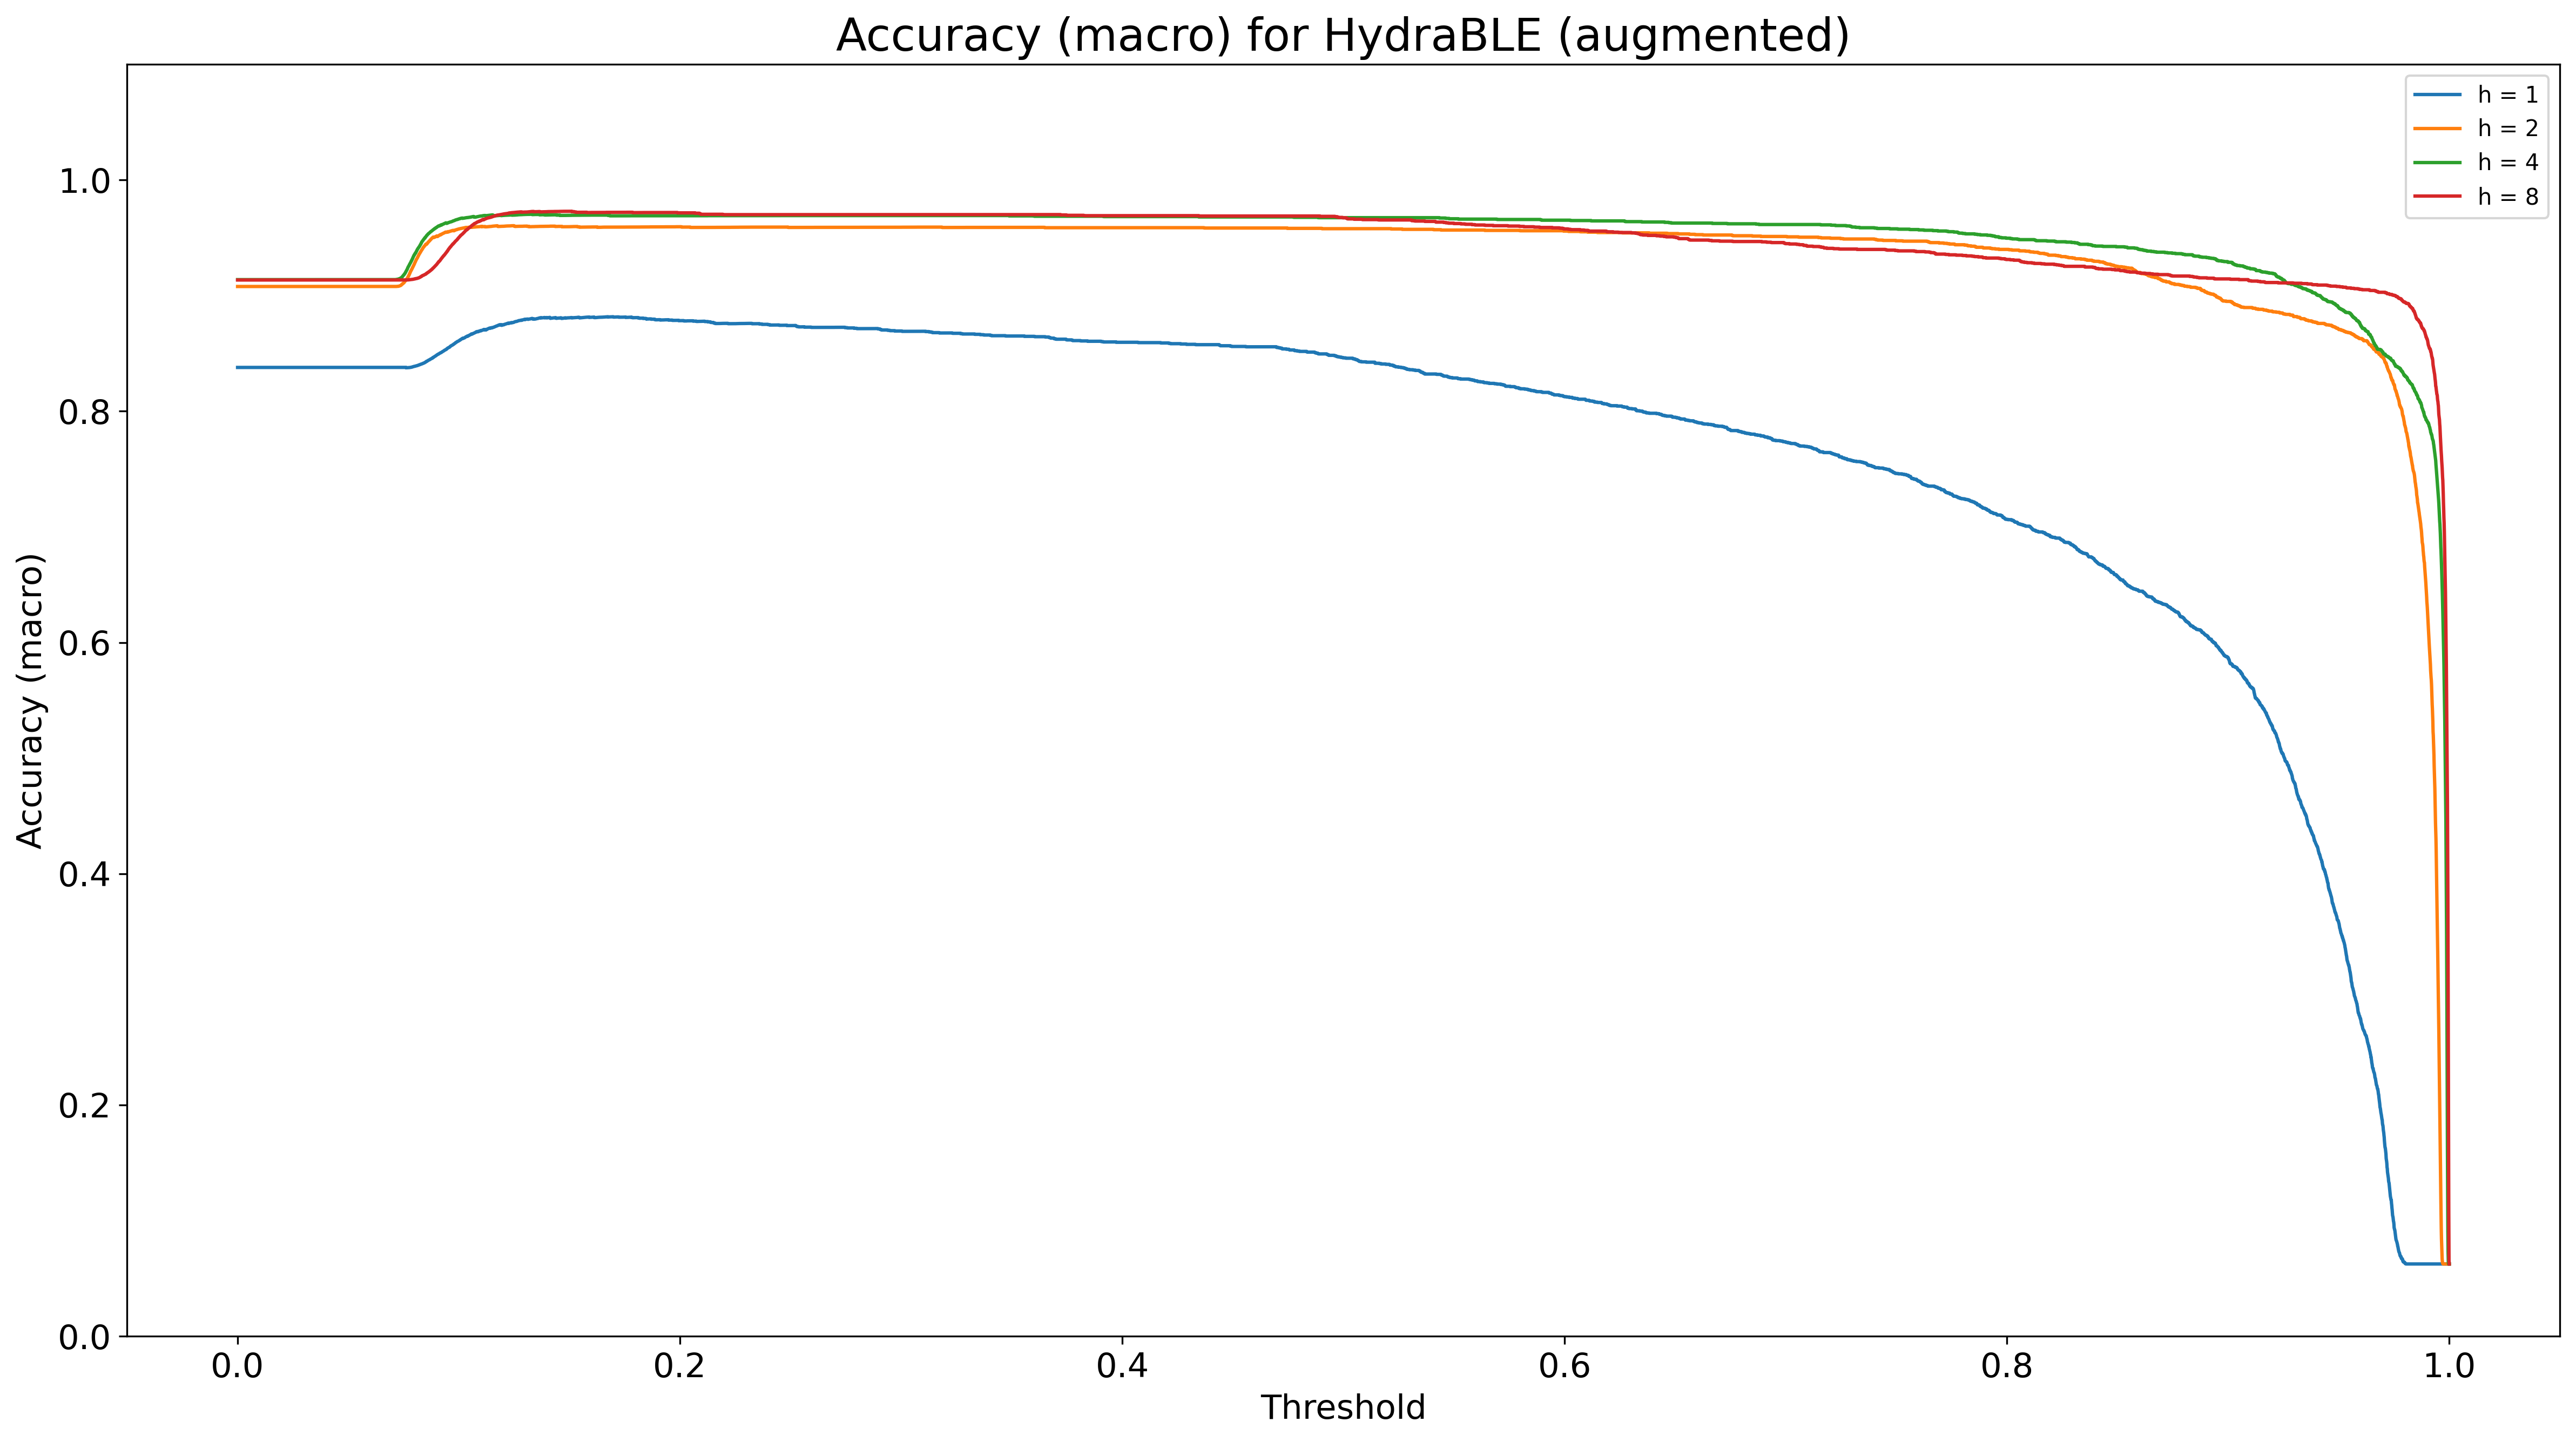

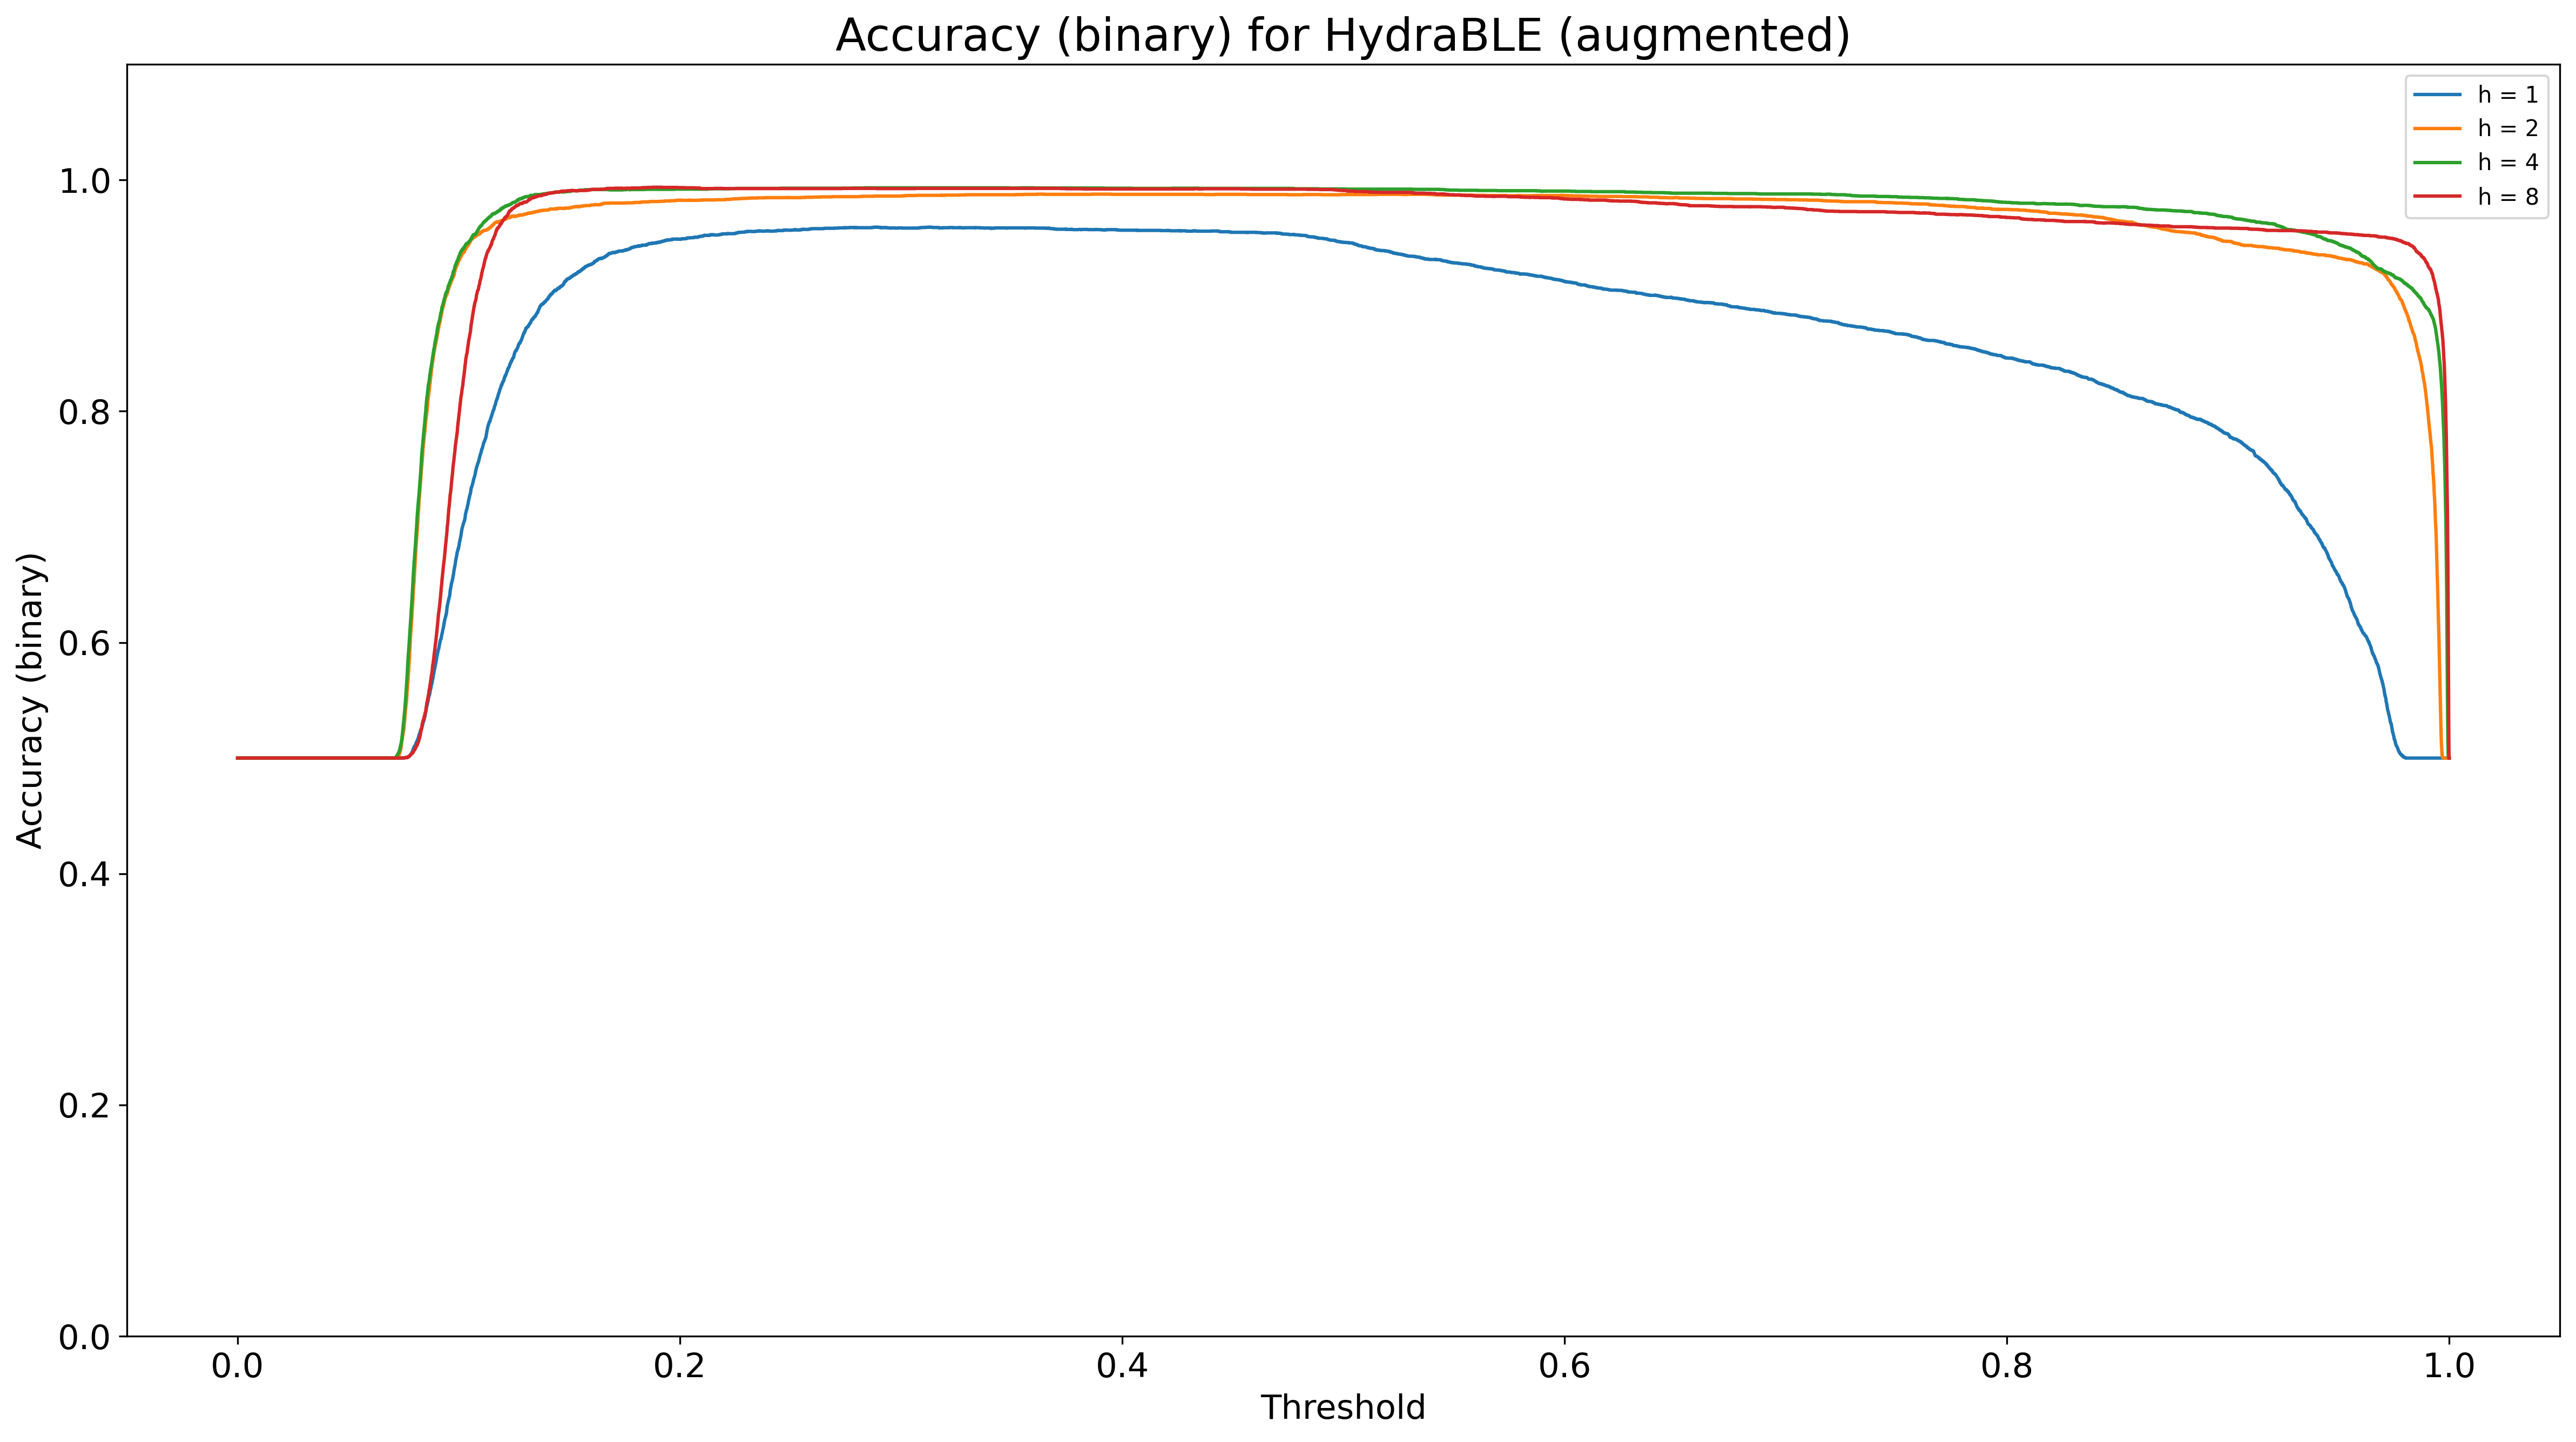

In [8]:
plot_curve(acc_micro_lut, "Accuracy (micro) for HydraBLE (augmented)", "Accuracy (micro)")
plot_curve(acc_macro_lut, "Accuracy (macro) for HydraBLE (augmented)", "Accuracy (macro)")
plot_curve(acc_binary_lut,  "Accuracy (binary) for HydraBLE (augmented)", "Accuracy (binary)")

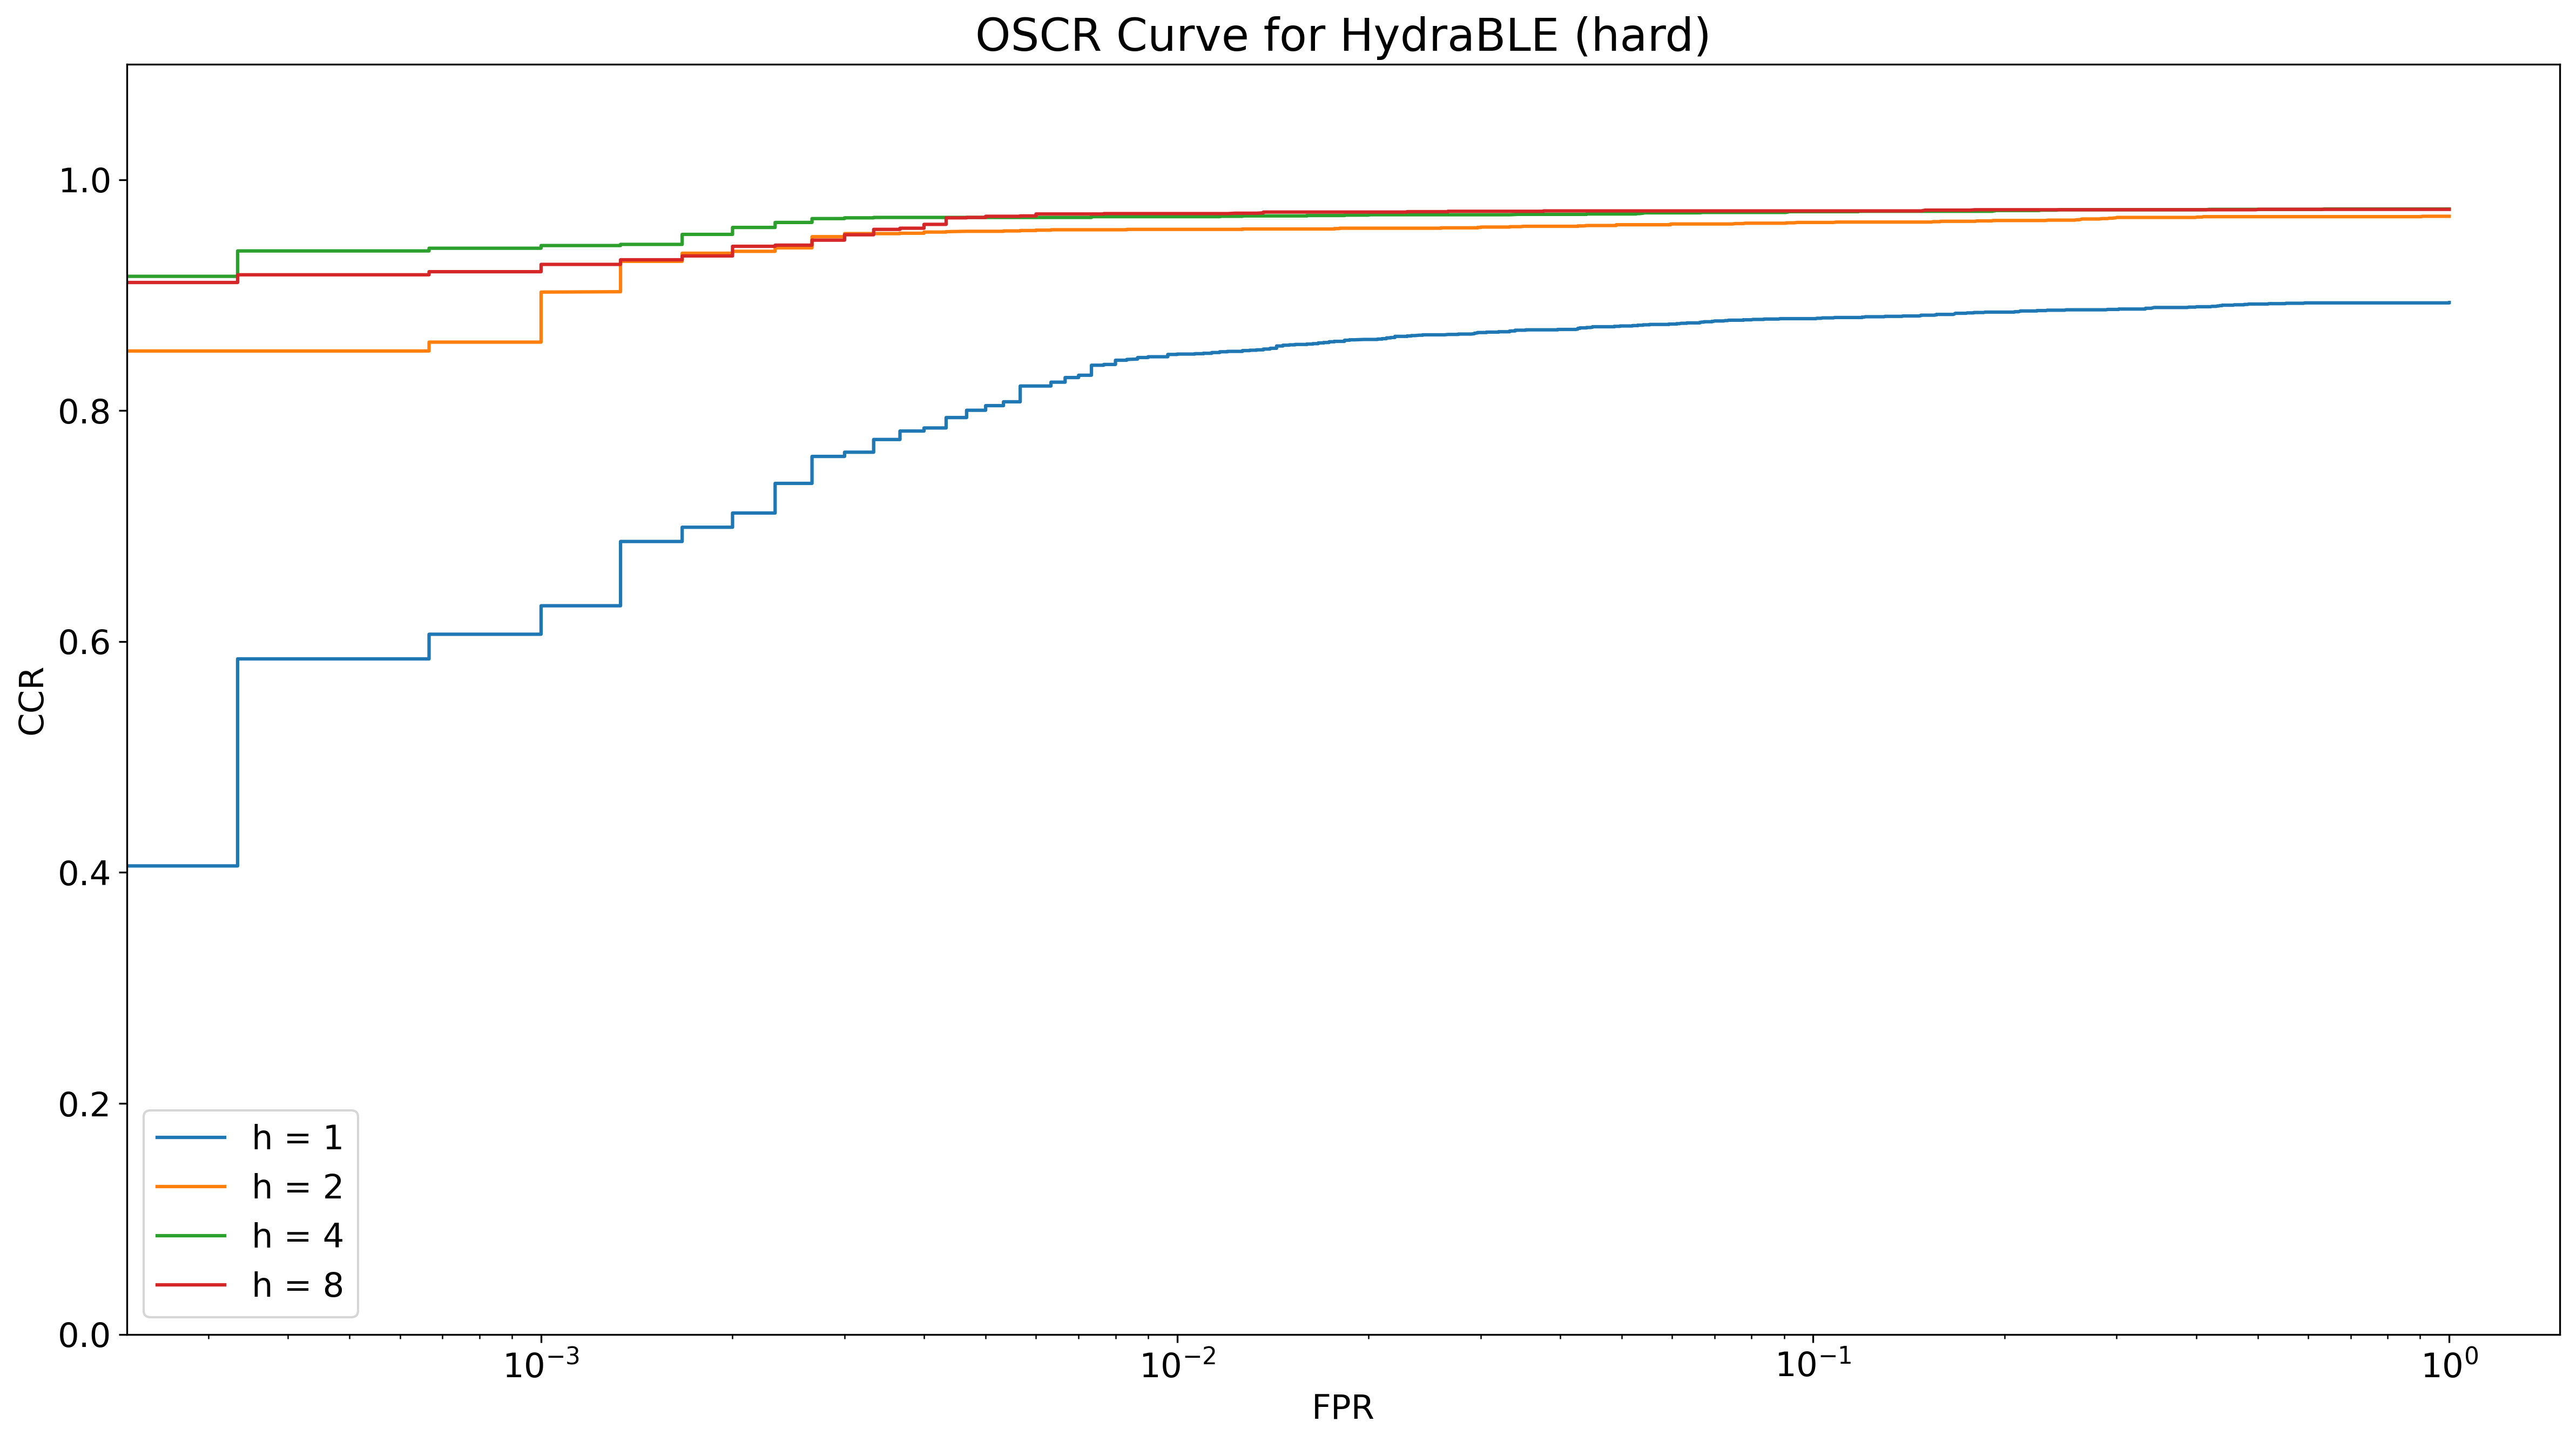

In [9]:

plt.figure(figsize=(16, 9), dpi = 300)

for h, values in oscr_lut.items():
    fprs = values[:, 0]
    ccrs = values[:, 1]

    plt.plot(fprs, ccrs, label=f"h = {h}")

plt.xticks(fontsize=FONTSIZE_TICKS)
plt.yticks(fontsize=FONTSIZE_TICKS)
plt.xlabel("Threshold", fontsize=FONTSIZE_LABEL)
plt.ylim(0, 1.1)
plt.xscale("log")
plt.ylabel("CCR", fontsize=FONTSIZE_LABEL)
plt.xlabel("FPR", fontsize=FONTSIZE_LABEL)
title = "OSCR Curve for HydraBLE (hard)"
plt.title(title, fontsize=FONTSIZE_TITLE)
plt.legend(fontsize=FONTSIZE_LABEL)
plt.tight_layout()
plt.savefig(plotPath + title + ".png", dpi = 300)
plt.show()

In [10]:
metrics = pd.DataFrame(np.array(metric_table).T, columns=("Metric", 1, 2, 4, 8))


In [11]:
metrics.to_csv(tablePath + "Metrics Table HydraBLE (augmented).csv", index = False)

In [12]:
metrics

,Metric,1,2,4,8
0,Accuracy (micro),0.9204999804496765,0.9751666784286499,0.9816666841506958,0.981333315372467
1,Accuracy (macro),0.8690208196640015,0.9583958387374878,0.9691250324249268,0.9693750143051147
2,Accuracy (binary),0.9583333134651184,0.987333357334137,0.9928333163261414,0.9923333525657654
3,CCR at FPR = 1e-1,0.8796666860580444,0.9629999995231628,0.9723333120346069,0.9729999899864197
4,CCR at FPR = 1e-2,0.8486666679382324,0.9570000171661377,0.9679999947547913,0.9706666469573975
5,CCR at FPR = 1e-3,0.606333315372467,0.859333336353302,0.940666675567627,0.9203333258628845
